In [4]:
!pip install handcalcs -q
!pip install Pillow -q

# Module 2: Hydrostatics 

In [2]:
import handcalcs.render
from sympy import symbols, Eq, solve
from math import sqrt,pi, cos, sin, radians,asin,atan,degrees, tan, log10
from PIL import Image

Global variables:

In [3]:
%%render param
g=9.81 #m/s2
rho_water=1000 #kg/m3
rho_Hg=13600 #kg/m3
p_atm=101325 #Pa

<IPython.core.display.Latex object>

## Problems for Lecture 5: Introduction to Hydrostatics

### Absolute Pressure, Gauge Pressure and Pressure  Head

---
#### Question 1 (*)[R]

The weather report states that the current atmospheric pressure is 970 mbar. 

a) Express the pressure as an absolute pressure measured in Pa. 

b) Express the pressure as an absolute pressure head of water.   

c) Express the pressure as a absolute pressure head of mercury (assume the density of mercury to be 13 600 kg/m<sup>3</sup>).

```{dropdown} Answer
$
a) \; 97 \; kPa
$

$
b) \; 9.89 \; m 
$

$
c) \; 0.73 \; m 
$
```


**Question 1 (a)**


```{dropdown} Hint
mbar means millibar

1 bar = 100 kPa

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=b293d241-8045-49f7-820a-b29d01757824)

```

**Solution**

In [7]:
%%render long 2
p_mbar=970 #mbar
p_bar= p_mbar*10**-3 #bar
p= p_bar*100*10**3 #Pa

<IPython.core.display.Latex object>

**Question 1 (b)**

```{dropdown} Hint
Water pressure head is how high water will rise in a vertical tube above the measuring point.
```

**Solution**

```{dropdown} Show code cell outputs

$$
p= \rho_{water}  \cdot g \cdot h_{water} 
$$

$$
h_{water}=\frac{p}{\rho_{water} \cdot g}
$$
```

In [8]:
%%render long 2
h_water= p/(rho_water*g) #m

<IPython.core.display.Latex object>

**Question 1 (c)**

**Solution**

In [9]:
%%render long 2
h_Hg= p/(rho_Hg*g) #m

<IPython.core.display.Latex object>

---
#### Question 2(*)

 If the pressure in a tank is 500 kPa. Find the equivalent pressure head of a) water b) mercury with density 13 600 kg/m<sup>3</sup> and c) heavy fuel oil with a specific gravity of 0.92. 

```{dropdown} Answer
$
a) \; 51 \; m
$

$
b) \; 3.7 \; m 
$

$
c) \; 55.4 \; m 
$
```


**Question 2 (a)**

```{dropdown} Hint
Water pressure head is how high water will rise in a vertical tube above the tank.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=caa2d2f3-abc5-4c73-a415-b29d01757a50)
```

**Solution**

In [10]:
%%render long 2
p=500 * 1000 #Pa
h_water= p/(g*rho_water) #m

<IPython.core.display.Latex object>

**Question 2 (b)**

**Solution**

In [11]:
%%render long 2
rho_Hg_=13600 #kg/m3
h_Hg= p/(g*rho_Hg_) #m

<IPython.core.display.Latex object>

**Question 2 (c)**


```{dropdown} Hint
Look up the definition of specific gravity.
```

**Solution**

In [12]:
%%render long 2
s= 0.92
rho_oil= s*rho_water #kg/m3
h_oil= p/(g*rho_oil) #m

<IPython.core.display.Latex object>

---
#### Question 3 (**)[R]

If the atmospheric pressure is 780 mbar and a gauge attached to a tank reads 330 mm Hg vacuum, what is the absolute pressure within the tank? Assume s<sub>Hg</sub> = 13.56.

```{dropdown} Answer
$
34 \; kPa
$
```


```{dropdown} Hint
For gauge pressure, atmospheric pressure is taken as the zero point.

Vacuum pressure is pressure below atmospheric pressure, i.e. negative pressure.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=ab6bb035-8f51-41e7-a8cc-b29d017586a2)
```

**Solution**

In [13]:
%%render long 2
s_Hg=13.56
h=-330/1000 #m
p_a=780*100 #Pa
rho_Hg= s_Hg*rho_water #kg/m3
p_gauge= h * rho_Hg * g #Pa
p_abs= p_gauge + p_a #Pa
p_abs_kPa= p_abs/1000 #kPa

<IPython.core.display.Latex object>

---
#### Question 4 (***)

A pressure gauge is connected to a tank filled with fluid under standard sea level conditions. The gauge shows a reading of 305 kPa. The gauge is then enclosed in a chamber as shown below, and the absolute pressure head in the chamber reduced to 100 mm Hg (the fluid pressure remains unchanged). What will the reading on the pressure gauge now be?

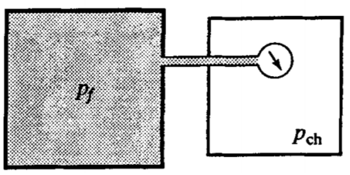

In [14]:
from PIL import Image
img = Image.open(r"figures/30.png")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
$
393 \; kPa
$
```


```{dropdown} Hint
A pressure gauge measures the difference between the measuring point and the pressure outside the gauge.

The gauge pressure reading will vary when changing the pressure outside the gauge, but the absolute pressure in the tank will be constant.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=7dcd31dc-aef3-45b8-83f7-b29d01759393)

```

**Solution**

```{dropdown} Show code cells outputs

$$
p_{abs}= p_{atm}+ p_{gauge}
$$ 


$$p_{chamber}=\rho \cdot g \cdot h_{Hg}$$

```

In [15]:
%%render long 1
p_gauge= 305*1000 #Pa
h_Hg= 100/1000 #m 
p_abs= p_atm+p_gauge#Pa
p_chamber= rho_Hg*g*h_Hg #Pa
p_gauge_2= p_abs-p_chamber #Pa
p_gauge2_kPa= p_gauge_2/1000 #kPa

<IPython.core.display.Latex object>

### Pressure Variation in Incompressible Fluids

---
#### Question 5 (*)

Calculate the gauge and absolute pressures at a depth of 10 m below a water surface under standard sea level conditions.

```{dropdown} Answer
$
98.1 \; kPa \; ; 199425.0 \; Pa
$
```


```{dropdown} Hint
Look up the definition of pressure head.

Look up the relation ship between absolute and gauge pressure.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=b1a0c0e7-9226-4cfe-ae23-b29d0175947a)
```

**Solution**

In [16]:
%%render long 1
h= 10 #m
p_gauge= rho_water*g*h #Pa
p_gauge_kPa= p_gauge/1000 #kPa
p_abs= p_atm+p_gauge #Pa

<IPython.core.display.Latex object>

---
#### Question 6 (*)[R]

The pressure vessel below contains glycerine to a depth of 2 m under pressure as shown. Find the pressure at the bottom of the tank.

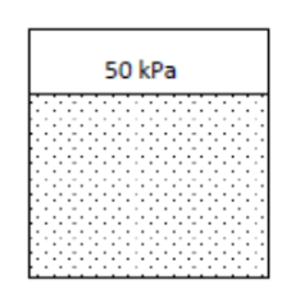

In [17]:
from PIL import Image
img = Image.open(r"figures/32.png")
base_width = 300  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
$
74.68 \; kPa
$
```


```{dropdown} Hint
The pressure at depth h below a point in an incompressible fluid is equal to the pressure at the point + $\rho gh$.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=858c2183-5454-4541-ad23-b29d01759590)
```

**Solution**

```{dropdown} Show code cell outputs

$\rho_{glycerine} =1258 kg/m^3$   Fluid properties table

```

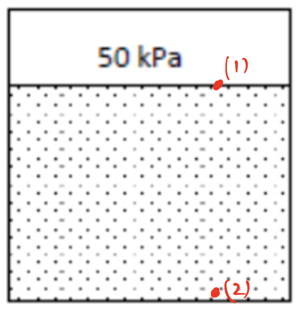

In [18]:
from PIL import Image
img = Image.open(r"figures/5_pressure_6.png")
base_width = 300  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [19]:
%%render long 2
h = 2 #m
p_1=50 *1000 #Pa
rho_glycerine=1258 #kg/m3
p_2= p_1+rho_glycerine*g*h #Pa
p_2_kPa= p_2/1000 #kPa

<IPython.core.display.Latex object>

---
#### Question 7 (**)[R]

An open tank contains 10 m of water, covered with 1 m of oil with s = 0.80. Find the absolute pressure at (a) the interface between the two fluids and (b) the bottom of the tank. 

```{dropdown} Answer
$
a) \; 109.1 \; kPa
$

$
b)\; 207.2 \; kPa
$
```


**Question 7 (a)**

```{dropdown} Hint
Since the tank is open, the atmospheric pressure will act on the surface of the oil.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=d058a33f-bf16-44e7-98ce-b29d0175981b)
```

**Solution**

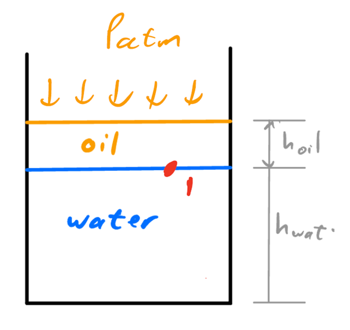

In [20]:
from PIL import Image
img = Image.open(r"figures/5_pressure_7a.png")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [21]:
%%render long 2
h_water= 10 #m
h_oil= 1 #m
s_oil= 0.8
rho_oil= s_oil*rho_water #kg/m3
p_abs1= p_atm+rho_oil*g*h_oil #Pa
p_abs1_= p_abs1/1000 #kPa

<IPython.core.display.Latex object>

**Question 7 (b)**

```{dropdown} Hint

The absolute pressure at the bottom of the tank is the absolute pressure at the top of the water (point 1) + $\rho gh$.
```

**Solution**

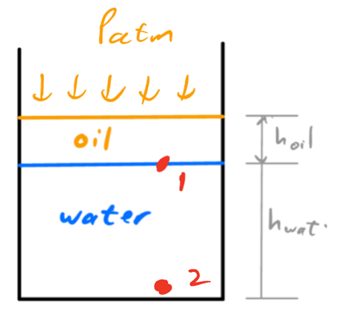

In [22]:
from PIL import Image
img = Image.open(r"figures/5_pressure_7b.png")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [23]:
%%render long 2
p_abs2= p_abs1+rho_water*g*h_water #Pa
p_abs2_= p_abs2/1000 #kPa

<IPython.core.display.Latex object>

---
#### Question 8 (**)

A pressure gauge at an elevation 4.8 m on the side of a storage tank containing oil reads 34.7 kPa. Another gauge at elevation 2.2 m reads 57.5 kPa. Calculate the specific weight, density and specific gravity of the oil. 

```{dropdown} Answer
$
8.77 \; kN/m^3 \; ; \; 894 kg/m^3 \; ; \; 0.894
$
```


```{dropdown} Hint
Calculate the height difference between the gauges.

Look up the definitions of the concepts in the question.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=b7d58227-4c86-4dc5-bc3e-b29d0175a635)
```

**Solution**

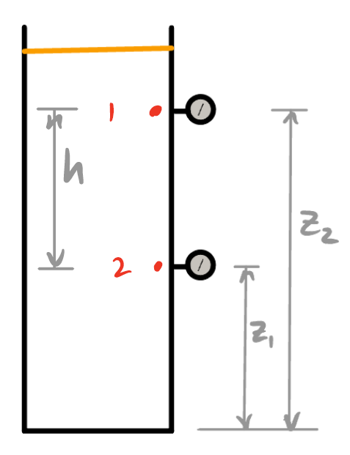

In [24]:
from PIL import Image
img = Image.open(r"figures/5_pressure_8.png")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Hint
$$ 
p_{2} = p_{1} + \rho \cdot g \cdot h 
$$

$$
\rho = \frac{p_{2} - p_{1}}{g \cdot h}
$$
```

In [25]:
%%render long 3
Z_1=4.8 #m
p_1= 34.7 *1000 #Pa
Z_2=2.2 #m
p_2= 57.5 *1000 #Pa
h= Z_1-Z_2 #m
rho= (p_2-p_1)/(g*h) #kg/m3
gamma_oil= rho*g/1000 #kN/m3
s_oil= rho/(rho_water) 

<IPython.core.display.Latex object>

---
#### Question 9 (**)

A closed vessel containing oil with a density of 830 kg/m<sup>3</sup> under pressure is shown below. The space above the oil is pressurised to 35 kPa above atmospheric pressure. Find the elevation of the oil surface in the attached tube. 

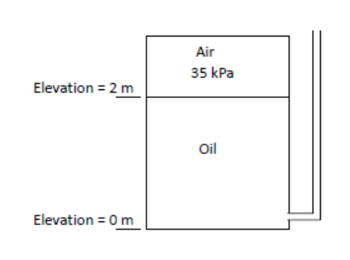

In [26]:
from PIL import Image
img = Image.open(r"figures/35.png")
base_width =  350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
$
6.3 \; m
$
```


```{dropdown} Hint
Select two points at the same elevation in the same continuous fluid.

One point can be selected at the surface of the oil.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=efba94ca-8800-4a3b-80c6-b29d0175bcd1)
```

**Solution**

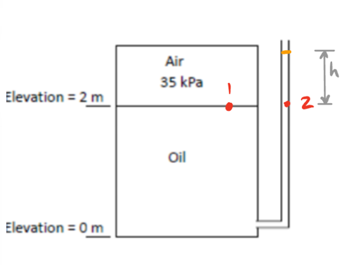

In [27]:
from PIL import Image
img = Image.open(r"figures/5_pressure_9.png")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs

$p_{1}=p_{2}$ Same elevation in a continuous, static fluid


$$
p_{1}=\rho_{oil}\cdot g \cdot h
$$

$$
h = g \frac{p_{1}}{\rho_{oil}}
$$
```

In [28]:
%%render long 1
rho_oil=830 #kg/m3
Z_1=2 #m
p_1=35000 #Pa
h= p_1/(rho_oil*g) #m
Z_oil= Z_1+h #m

<IPython.core.display.Latex object>

---
#### Question 10 (**)[R]

Calculate the level h of the oil in the right-hand tube in the figure below.

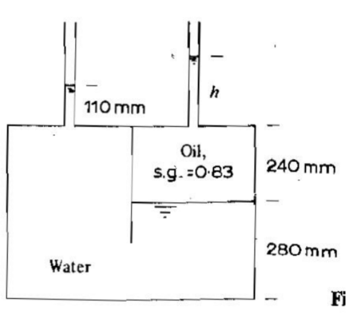

In [29]:
from IPython.display import display, HTML
img = Image.open(r"figures/36.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img 

```{dropdown} Answer
$
181.69 \; mm
$
```


```{dropdown} Hint
Use gauge pressure.

Select two points at the same elevation in a continuous fluid.

Then equate their pressures.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=dd3e4563-ed93-4895-8d37-b2a00038d544)
```

**Solution**

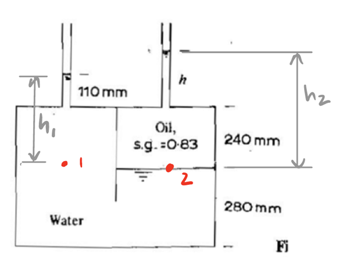

In [30]:
from PIL import Image
img = Image.open(r"figures/5_pressure_10.png")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
$p_1=p_2$ Same elevation in a continuous, static fluid.

$$
\rho_{water}\cdot g \cdot h_{1} = \rho_{oil}\cdot g \cdot h_{2}
$$

$$
\rho_{water} \cdot h_{1} = \rho_{oil} \cdot h_{2}
$$

$$
h_{2} = \frac{\rho_{water}\cdot h_{1}}{\rho_{oil}}
$$
```

In [31]:
%%render long 2
s=0.83 
h_1 =110 + 240 #mm

rho_oil = s*rho_water #kg/m3
h_2=(rho_water*h_1)/rho_oil #Pa
h= h_2 -240 #mm

<IPython.core.display.Latex object>

---
#### Question 11 (**)

An open tube is attached to a tank as shown below. If the water rises to a height of 800 mm in the tube, what are the pressures p<sub>a</sub> and p<sub>b</sub> of the air above the water? Neglect capillary effects. 

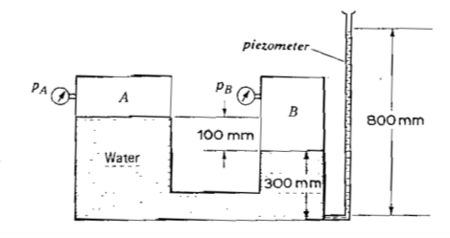

In [32]:
from PIL import Image
img = Image.open(r"figures/37.png")
base_width = 450  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img 

```{dropdown} Answer
$
3924 \; Pa \; ; \; 4905 \; Pa
$
```


```{dropdown} Hint
Use gauge pressure.

Select two points at the same elevation in a continuous fluid.

Then equate their pressures.

The pressure in a gas (air) can be assumed as uniform.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=db1f75b5-8ec7-4980-99fb-b2a00038ba71)
```

**Solution**

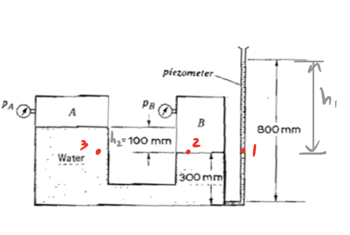

In [33]:
from PIL import Image
img = Image.open(r"figures/5_pressure_11.png")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
$p_{1} = p_{2}$  Same elevation in a continuous, static fluid

$$
\rho_{w}\cdot g \cdot h_{1} = p_{B}
$$

$p_{1} = p_{3}$  Same elevation in a continuous, static fluid

$$
\rho_{w}\cdot g \cdot h_{1} = p_{A} + \rho_{w}\cdot g \cdot h_{2}
$$

$$
p_{A} = \rho_{w}\cdot g (h_{1}- h_{2})
$$
```

In [34]:
%%render long 2
h_1= 800-300 #mm
h_2= 100 #mm
p_B=rho_water*g*h_1/1000 #pa
p_A= rho_water*g*(h_1-h_2)/1000 #Pa

<IPython.core.display.Latex object>

---
#### Question 12 (***)

A submarine is situated 1000 m below sea level. The pressure inside the submarine is controlled. If water inside the submarine boils at a temperature of 90°C, what is the pressure difference between the inside and outside of the submarine? Take the density of sea water as 1 023 kg/m<sup>3</sup>. 

```{dropdown} Answer
$
10.1 \; MPa
$
```


```{dropdown} Hint
The pressure outside the submarine can be determined from the depth below water.

Work consistently in absolute or gauge pressure.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=7377b51c-1ab9-48a2-aef0-b2a00038ba60)
```

**Solution**

```{dropdown} Show code cell outputs
The absolute pressure inside the submarine can be determined from water properties table.

Saturation vapour pressure of water at 90℃:

$$
p_{in}=p_v= 70.1 kPa
$$
```

In [35]:
%%render long 2
h=1000 #m
rho_sea_water=1023 #kg/m3
g = 9.81 #m/s2

p_out = p_atm + rho_sea_water * g * h  #Pa abs

p_in=70.1 *1000 #Pa
Delta_p= (p_out - p_in) #Pa
Delta_p_MPa = Delta_p/1000000 #MPa

<IPython.core.display.Latex object>

## Problems for Lecture 6: Manometry

### Piezometers

---
#### Question 1 (*)

A piezometer is attached to the top of a pressure vessel with a pressure of 25 kPa. If the vessel is filled with a fluid that has a specific gravity of 1.85, how high would the fluid rise in the piezometer?

```{dropdown} Answer

$1.38 \; m$
```

```{dropdown} Hint

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=f792cf21-34d3-439c-aa24-b2a00038b955)
```

**Solution**

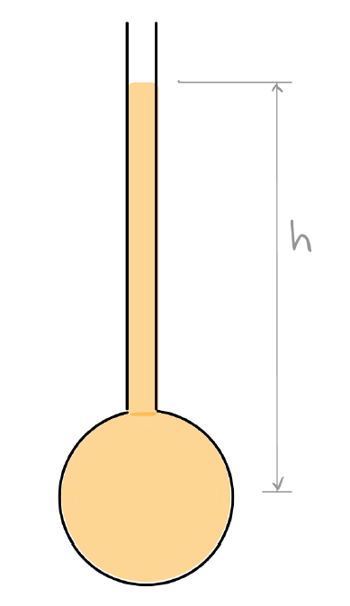

In [36]:
from PIL import Image
img = Image.open(r"figures/6_manometry_1.png")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs

$$
p= \rho_{fluid} \cdot g \cdot h\\
h=\frac{p}{\rho_{fluid} \cdot g}
$$  

```

In [37]:
%%render long 2
p=25000 #Pa
s_fluid=1.85
rho_fluid= s_fluid*rho_water #kg/m3
h= p/(rho_fluid*g) #m

<IPython.core.display.Latex object>

---
#### Question 2 (**)

An open tank has two piezometers attached to its side as shown below. The tank contains two immiscible (non-mixing) liquids. Find the a) elevation of the liquid surface in piezometer A, b) elevation of the liquid surface in piezometer B and c) the pressure at the bottom of the tank.

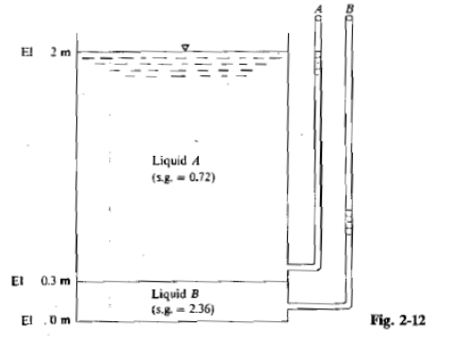

In [38]:
from PIL import Image
img = Image.open(r"figures/40.png")
base_width = 450  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img 

```{dropdown} Answer

a) $2 \; m$  
b) $0.82 \; m$  
c) $18.9 \; kPa$  

```

**Question 2 (a)**

```{dropdown} Hint

Use gauge pressure.

Select two points at the same elevation in the same continuous fluid.

Then equate their pressures.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=6d046846-6b2b-4626-b065-b2a00038b916)

```

**Solution**

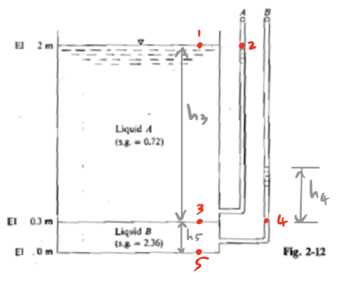

In [39]:
from PIL import Image
img = Image.open(r"figures/6_manometry_2.png")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
$p_{1} = p_{2}$  Same elevation in a continuous, static fluid.

Since $p_1$ is atmospheric, $p_2$ must also be atmospheric.

Thus $Z_2=Z_1=2m$
```

**Question 2 (b)**

```{dropdown} Hint

Use gauge pressure.

Select two points at the same elevation in the same continuous fluid.

Then equate their pressures.

```

**Solution**

```{dropdown} Show code cell outputs
$p_3 = p_4$  Same elevation in the same continuous fluid.

$$
\rho_{A}\cdot g \cdot h_{3} = \rho_{B} \cdot g \cdot h_{4}
$$

$$
\rho_{A} \cdot h_{3} = \rho_{B} \cdot h_{4}
$$

$$
h_{4} = h_{3} \frac{\rho_{A}}{\rho_{B}}
$$

```

In [40]:
%%render long 2
h_3=2-0.3 #m
s_A=0.72 
s_B=2.36

rho_A=s_A*rho_water # kg/m3
rho_B= s_B*rho_water #kg/m3
h_4= h_3 * (rho_A/rho_B)
Z_B_surface= 0.3 + h_4 #m

<IPython.core.display.Latex object>

**Question 2 (c)**

```{dropdown} Hint
The pressure at the bottom is the sum of the pressure exerted by Liquid A and Liquid B
```

**Solution**

In [41]:
%%render long 2
h_5= 0.3 #m
p_5 = rho_A*g*h_3 + rho_B*g*h_5 #Pa
p_5 = p_5/1000 #kPa

<IPython.core.display.Latex object>

### Barometers

---
#### Question 3(*)

What is the atmospheric pressure if a mercury barometer reads 742 mm? Work from basic principles. Assume &rho;<sub>Hg</sub> = 13 600 kg/m<sup>3</sup>.

```{dropdown} Answer

$99 \; kPa$ 

```

```{dropdown} Hint

Look up what a mercury barometer looks like.

Assume the saturation vapour pressure of Hg is negligibly small.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=82d0e970-501e-4dad-9b85-b2a00038b839)

```

**Solution**

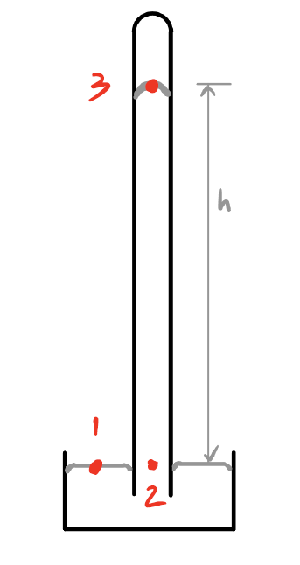

In [42]:
from PIL import Image
img = Image.open(r"figures/6_manometry_3.png")
base_width = 300 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
$p_1=p_2$ Same elevation in continuous static fluid

$$
p_{atm} = p_3 + \rho_{Hg} \cdot g \cdot h
$$

Assume $p_3$ (saturation vapour pressure of Hg) negligibly small
```

In [43]:
%%render long 1
h=0.742 #m
rho_Hg_=13600 #kg/m3

p_atm= rho_Hg_*g*h #Pa
p_kPa= p_atm/1000 #kPa

<IPython.core.display.Latex object>

---
#### Question 4 (***)

A scientist plans to build a water barometer. When the atmospheric pressure is 990 mb abs and the water temperature 70°C, what would you expect the barometer reading to be?

```{dropdown} Answer

$7.07 \; m$ 

```

```{dropdown} Hint
The vapour pressure of water at 70 ℃ is not negligible.

Look up the true density of water at this temperature.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=25d7d54a-9776-49fb-935d-b2a00038b7f6)
```

**Solution**

```{dropdown} Show code cell outputs

$p_{1}= p_{2}$  Same elevation in a continuous static fluid.

$$
p_{atm}= p_3+\rho_{wat}\cdot g \cdot h
$$ 

$$
h = \frac{p_{atm}-p_{3}}{\rho_{wat}\cdot g}
$$

$p_{3}=31.16 kPa$  water properties table for T = 70℃


$\rho_{wat}=977.8kg/m3 kPa$  properties table for T = 70℃

```

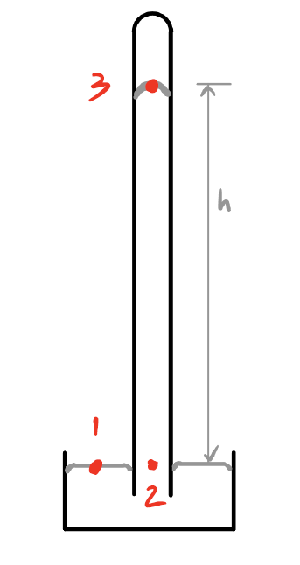

In [44]:
from PIL import Image
img = Image.open(r"figures/6_manometry_3.png")
base_width = 300 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [45]:
%%render long 2
p_3=31.16 * 1000 #Pa
p_atm_ex = 990*100 #Pa
rho_wat = 977.8 #kg/m

h = (p_atm - p_3)/(rho_wat*g) #m

<IPython.core.display.Latex object>

---
#### Question 5 (***)

A mercury barometer has a reading of 750 mm. Sketch this scenario and work from basic principles to calculate the atmospheric pressure. What is the impact on the reading of ignoring Mercury’s vapour pressure? Assume &rho;<sub>Hg</sub> = 13 550 kg/m<sup>3</sup>.

```{dropdown} Answer
 
 $99.69 \; kPa \;; 0.0002 \; \% \; ; negligible$

```

```{dropdown} Hint
Look up what a barometer looks like.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=807cd5f5-5130-4728-846a-b2a00038ac82)

```

**Solution**

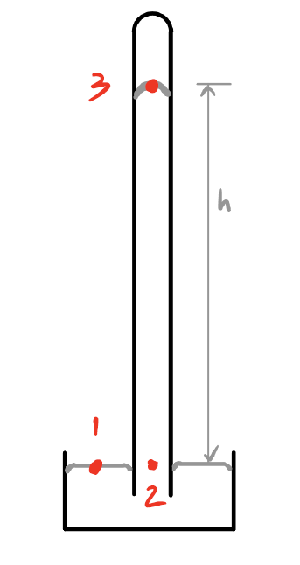

In [46]:
from PIL import Image
img = Image.open(r"figures/6_manometry_3.png")
base_width = 300 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
$p_{atm}=p_1=p_2$ Same elevation in continuous static fluid

Considering mercury's vapour pressure
$p_{atm_con} = p_3 + \rho_{Hg} \cdot g \cdot h$

Ignoring mercury's vapour pressure
$p_{atm_ign} = \rho_{Hg} \cdot g \cdot h$
```

In [47]:
%%render long 4

h=0.75 #m
rho_Hg_=13550 #kg/m3

p_3=0.17 #N/m2
p_atm_con= p_3+(rho_Hg_*g*h) #Pa
p_atm_ign= rho_Hg_*g*h #Pa
Effect_Hg= (0.17/p_atm_con)*100 #%

<IPython.core.display.Latex object>

### Manometers

---
#### Question 6 (**)[R]

A manometer is attached to a water tank as shown below. Find the height of the free water surface above the bottom of the tank. Work from basic principles. Assume ρ<sub>Hg</sub> = 13 600 kg/m<sup>3</sup>.

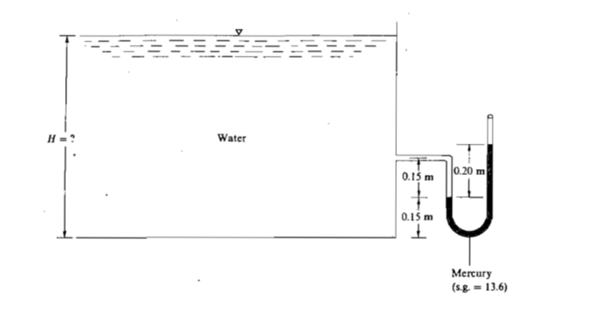

In [48]:
from PIL import Image
img = Image.open(r"figures/44.png")
base_width = 600  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$2.87 \; m$ 

```

```{dropdown} Hint
Use gauge pressure.

Select two points at the same elevation in the same elevation in a continous fluid.

Then equate their pressures.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=25aa744e-a602-4ba1-8b89-b2a00038abc2)

```

**Solution**

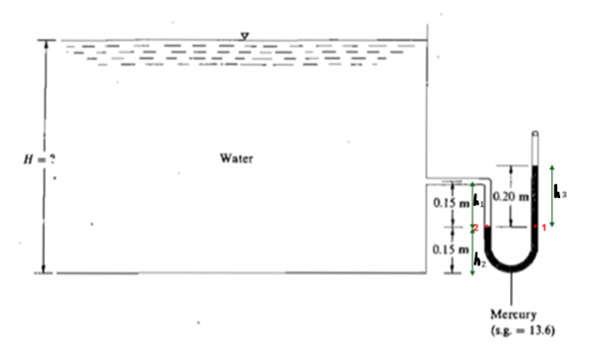

In [49]:
from PIL import Image
img = Image.open(r"figures/6_manometry_6.png")
base_width = 600  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs

$p_1 = p_2$   Same elevation in continuous static fluid

$$
\rho_{Hg} \cdot g \cdot h_3=\rho_{wat} \cdot g(H-h_2)
$$

$$
\rho_{Hg} \cdot h_3=\rho_{wat} (H-h_2)
$$

$$
H = \frac{\rho_{Hg} h_3}{\rho_{wat}} + h_2
$$
```


In [50]:
%%render long 2

rho_Hg_= 13600 #kg/m3
h_2= 0.15 #m
h_3= 0.20 #m

H= (rho_Hg_*h_3)/(rho_water)+h_2 #m

<IPython.core.display.Latex object>

---
#### Question 7 (**)[R]

Calculate the difference in manometer mercury levels (y) in the figure below from basic principles. Assume ρ<sub>Hg</sub> = 13 600 kg/m<sup>3</sup>.

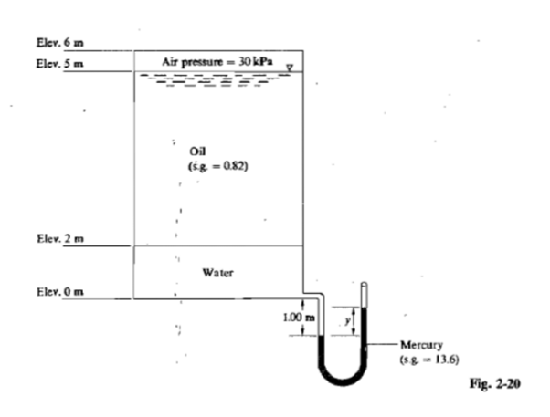

In [51]:
from PIL import Image
img = Image.open(r"figures/6_problem_7.png")
base_width = 550 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$626 \; mm$ 

```

```{dropdown} Hint
Use gauge pressure.

Select two points at the same elevation in the same elevation in a continous fluid.

Then equate their pressures.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=2973dc87-4bd2-4e15-b7b7-b2a000389869)

```

**Solution**

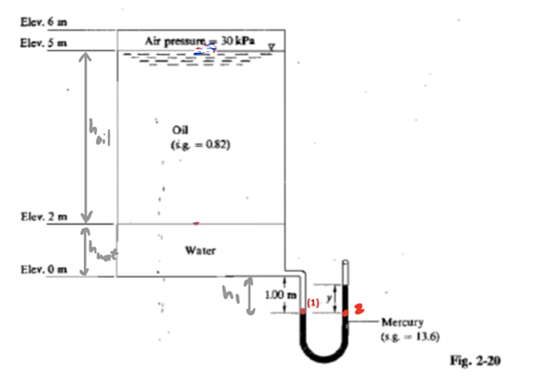

In [52]:
from PIL import Image
img = Image.open(r"figures/6_manometry_7.png")
base_width = 550 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs

$p_1 = p_2$   Same elevation in continuous static fluid

$$
p_{air} + \rho_{oil}\cdot g \cdot h_{oil} + \rho_{wat}\cdot g \cdot h_{wat} + \rho_{wat}\cdot g \cdot h_{1} = y \rho_{Hg}\cdot g
$$

$$
y = \frac{p_{air} + \rho_{oil}\cdot g \cdot h_{oil} + \rho_{wat}\cdot g \cdot (h_{wat}+h_{1})}{\rho_{Hg}\cdot g}
$$

```

In [53]:
%%render long 2

rho_Hg_=13600 #kg/m3
s_oil=0.82
h_oil = 5-2 #m
h_wat = 2 #m
h_1 = 1 #m
p_air=30000 #Pa

rho_oil= s_oil*rho_water #kg/m3
y = (p_air + rho_oil*g*h_oil + rho_wat*g*(h_wat+h_1))/(rho_Hg_*g) #m


<IPython.core.display.Latex object>

---
#### Question 8 (**)

Calculate the pressure p<sub>A</sub> in the figure below if the specific gravity of the oil is 0.82. Assume ρ<sub>Hg</sub> = 13 600 kg/m<sup>3</sup>

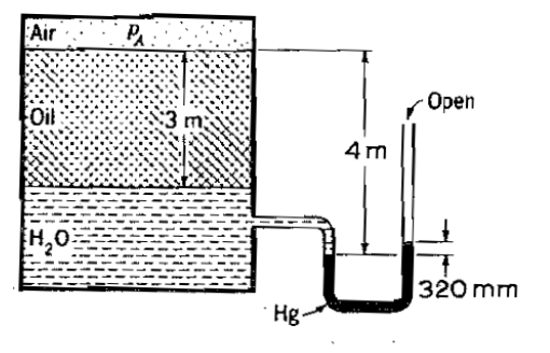

In [54]:
from PIL import Image
img = Image.open(r"figures/46.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$8750.52 \; Pa$ 

```

```{dropdown} Hint
Use gauge pressure.

Select two points at the same elevation in a continous fluid.

Then equate their pressures.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=34edb654-effe-4be1-9424-b2a00038a9b2)

```

**Solution**

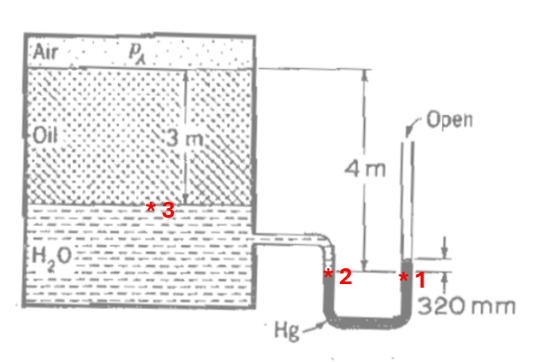

In [55]:
img2 = Image.open(r"figures/46s.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img2.size[0])
h_size = int(float(img2.size[1]) * w_percent)
resized_img = img2.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs

$p_1= p_2 $   Same elevation in continuous static fluid.

$$
\rho_{Hg}\cdot g \cdot h_{Hg} = p_A + \rho_{oil}\cdot g \cdot h_{oil} + \rho_{wat}\cdot g \cdot h_{wat}
$$

$$
p_A = \rho_{Hg}\cdot g \cdot h_{Hg} - \rho_{oil}\cdot g \cdot h_{oil} - \rho_{wat}\cdot g \cdot h_{wat}
$$

```

In [56]:
%%render long 2

rho_Hg_= 13600 #kg/m3
s_oil= 0.82
h_oil= 3 #m
h_Hg= 320 /1000 # m
h_2= 4 #m 

rho_oil=s_oil*rho_water # kg/m3
p_A= rho_Hg_*g*h_Hg-(rho_water*s_oil*g*h_oil)-rho_water*g*(h_2-h_oil) #Pa

<IPython.core.display.Latex object>

---
#### Question 9 $(*)$ $(**) $ $(***)$

A mercury manometer is used to measure the pressure in a vessel containing water as shown in the figure below. The following measurements were taken:  
$h_1$ = 300mm and $h_2$ = 150mm.  

a.* What was the pressure in the vessel at its center (point A) based on the measured values?  
b.** If the diameter of the pressure vessel is 2m, what is the pressure at its bottom?  
c.*** It is later discovered that an air bubble with an effective height of 10 mm was trapped in the water of the left leg of the manometer when the readings were taken. Calculate the corrected pressure in the container if this bubble is taken into consideration.


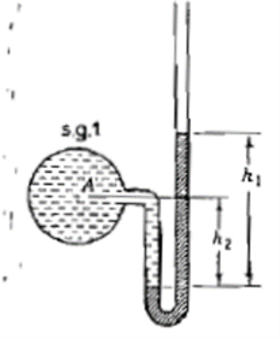

In [57]:
from PIL import Image
img = Image.open(r"figures/47.png")
base_width = 280  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
 
 a) $38.4 \; kPa$  
 b) $48.2 \; kPa$  
 c) $38.5 \; kPa$  
 
```

**Question 9 (a)**

```{dropdown} Hint
Use gauge pressure.

Select two points at the same elevation a continous fluid.

Then equate their pressures.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=7fe1e1ed-40bf-4951-89cc-b2a00038a581)
```

**Solution**

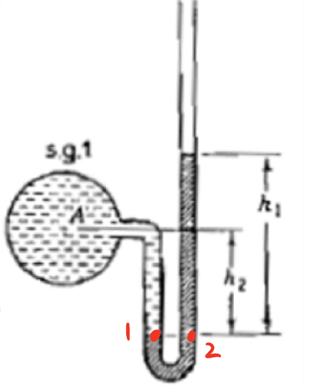

In [58]:
from PIL import Image
img = Image.open(r"figures/6_manometry_9_a.png")
base_width = 330 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs

$p_1= p_2 $  Same elevation in continuous static fluid.

$$
p_A+\rho_{water} \cdot g \cdot h_2=\rho_{Hg} \cdot g \cdot h_1
$$

$$
p_A=\rho_{Hg} \cdot g \cdot h_1-\rho_{water} \cdot g \cdot h_2
$$

```

In [59]:
%%render long 2

h_1=0.3 #m
h_2=0.15 #m
d=2 #m
h_bubble=0.01 #m

rho_Hg_= 13550 #kg/m3
p_A= rho_Hg_*g*h_1-rho_water*g*h_2 #Pa
p_A_= p_A/1000 #kPa

<IPython.core.display.Latex object>

**Question 9 (b)**

**Solution**

```{dropdown} Show code cell outputs
The pressure at the bottom is equal to the pressure in the centre of the pressure vessel plus the pressure difference from the centre to the bottom.
```

In [60]:
%%render long 2
p_bottom= p_A+rho_water*g*(d/2) #Pa
p_bottom_= p_bottom/1000 #kPa

<IPython.core.display.Latex object>

**Question 9 (c)**

**Solution**

```{dropdown} Show code cell outputs
The bubble reduces the height of the water by 10mm, therefore the pressure in the container is:  

$$
p_A=\rho_{Hg} \cdot g \cdot h_1-\rho_{water} \cdot g \cdot (h_2-h_{bubble})
$$
```

In [61]:
%%render long 2
p_A= rho_Hg_*g*h_1-rho_water*g*(h_2-h_bubble) #Pa
p_A_= p_A/1000 #kPa

<IPython.core.display.Latex object>

---
#### Question 10 (**)[R]

What is the pressure difference between points A and B in the system below? Work from basic principles. Assume ρ<sub>Hg</sub> = 13550 kg/m<sup>3</sup>.

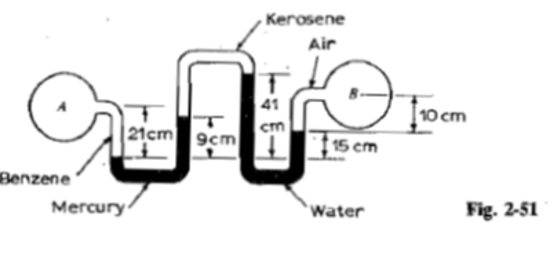

In [62]:
from PIL import Image
img = Image.open(r"figures/48.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$10.1 \; kPa$ 

```

```{dropdown} Hint
Use the principles that

-Pressure is the same at the same elevation in a continuous static fluid.

-Pressure at a different elevation in the same continuous fluid can be calculated using 𝜌𝑔ℎ.

-Work systematically from one side of the setup to the other.

-The pressure in a gas (air) can be assumed as uniform.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=9d041c52-2c2d-4579-9d40-b2a000389862)
```

**Solution**

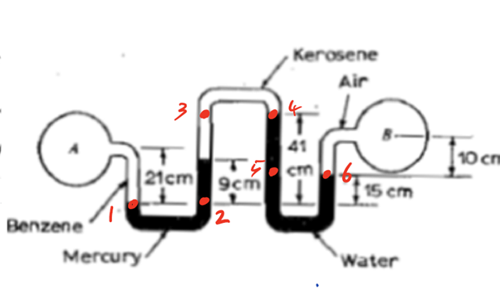

In [63]:
from PIL import Image
img = Image.open(r"figures/6_manometry_10.png")
base_width = 500  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
$p_1=p_2, p_3=p_4, p_5=p_6$.  Same elevation in continuous static fluid.


$p_1=p_2$

$$
p_A + \rho_{benz} \cdot g \cdot h_{benz} = p_3 + \rho_{kero} \cdot g \cdot h_{kero} + \rho_{Hg} \cdot g \cdot h_{Hg}
$$

$p_A + \rho_{benz} \cdot g \cdot h_{benz} = p_4 + \rho_{kero} \cdot g \cdot h_{kero} + \rho_{Hg} \cdot g \cdot h_{Hg} $ (1)

but $p_5=p_6$

$$
p_4 + \rho_{wat} \cdot g \cdot h_{wat} = p_B
$$

$$
p_4 = p_B - \rho_{wat} \cdot g \cdot h_{wat} 
$$

replace into (1):

$$
p_A + \rho_{benz} \cdot g \cdot h_{benz} = p_B - \rho_{wat} \cdot g \cdot h_{wat} + \rho_{kero} \cdot g \cdot h_{kero} + \rho_{Hg} \cdot g \cdot h_{Hg}
$$

$$
p_A -p_B  = \rho_{kero} \cdot g \cdot h_{kero} + \rho_{Hg} \cdot g \cdot h_{Hg} - \rho_{wat} \cdot g \cdot h_{wat} - \rho_{benz} \cdot g \cdot h_{benz}
$$
```

In [64]:
%%render long 2
rho_Hg_= 13550 #kg/m3
rho_benz=876 #kg/m3
rho_kero= 808 #kg/m3
h_benz= 21/100 #m 
h_Hg= 9/100 #m 
h_wat= (41-15)/100 #m 
h_kero = (41-9)/100 #m

Delta_p_AB= rho_kero*g*h_kero + rho_Hg_*g*h_Hg - rho_water*g*h_wat - rho_benz*g*h_benz #Pa

<IPython.core.display.Latex object>

### Inverted Manometers

---
#### Question 11 (***)

In the figure below, the liquid at A and B is water and the manometer liquid is oil with s = 0.80, h<sub>1</sub> = 300 mm, h<sub>2</sub> = 200 mm, and h<sub>3</sub> = 600 mm. a) Determine the difference between the pressures at A and B. b) if pB = 50 kPa and the barometer reading is 730 mm Hg, find the absolute pressure head at A in meters of water. Assume ρ<sub>Hg</sub> = 13600 kg/m<sup>3</sup>.

```{dropdown} Answer

 a) $-1.37 \; kPa$  
 b) $15.02 \; m abs$

```

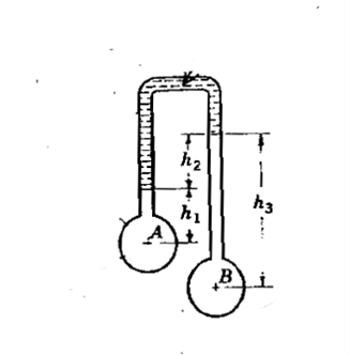

In [65]:
from PIL import Image
img = Image.open(r"figures/49.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

**Question 11 (a)**

```{dropdown} Hint

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=744cfb14-e202-4a7a-b6fc-b2a00038985d)
```

**Solution**

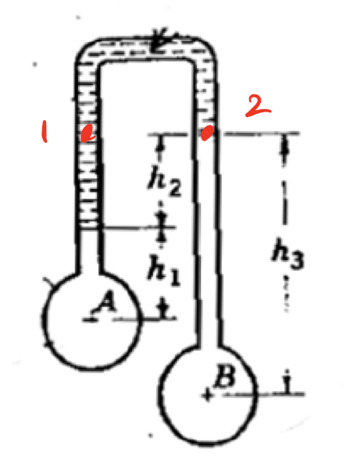

In [66]:
from PIL import Image
img = Image.open(r"figures/6_manometry_11_a.png")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

 ```{dropdown} Show code cell outputs
$p_1=p_2$  (1)     Same elevation in continuous, static fluid. 


but $p_A = p_1 + \rho_{oil} gh_2 + \rho_{wat} gh_1$      (2)

and $p_B = p_2 + \rho_{wat} gh_3$                        (3) 

Replace (2) and (3) into (1)

$$
p_A - \rho_{oil} gh_2 - \rho_{wat} gh_1 = p_B - \rho_{wat} gh_3
$$

$$
p_A - p_B = \rho_{oil} gh_2 + \rho_{wat} gh_1 - \rho_{wat} gh_3
$$

$$
p_A - p_B = \rho_{wat} s_oil gh_2 + \rho_{wat} gh_1 - \rho_{wat} gh_3
$$
 ```

In [67]:
%%render long 2

s_oil=0.8
h_1=0.3 #m
h_2=0.2 #m
h_3=0.6 #m

Delta_p_AB = rho_water*s_oil*g*h_2 + rho_water*g*h_1 - rho_water*g*h_3 #pa

<IPython.core.display.Latex object>

**Question 11 (b)**

**Solution**

```{dropdown} Show code cell outputs

$$p_A=p_B+ \Delta p_{AB}$$  

```

In [68]:
%%render long 2

p_B=50000 #Pa
h_Hg= 0.730 #m Hg
rho_Hg_=13600 #kg/m3

p_A= p_B - Delta_p_AB #Pa
p_atm_ = rho_Hg*g*h_Hg #Pa
p_A_abs = p_B + p_atm_ #Pa abs
h_A_abs = p_A_abs/(rho_water*g) #m abs

<IPython.core.display.Latex object>

---
#### Question 12 (***)[R]

Calculate the pressure at A in the figure below. Work from basic principles. Assume ρ<sub>Hg</sub> = 13550 kg/m<sup>3</sup>.

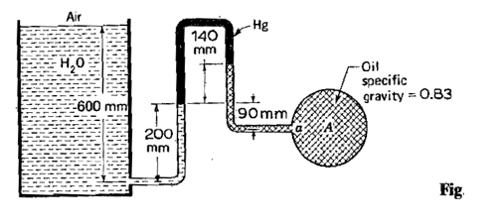

In [69]:
from PIL import Image
img = Image.open(r"figures/50.png")
base_width = 500  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

 $-12.8 \; kPa$

```

```{dropdown} Hint
Use gauge pressure.

Select two points at the same elevation in a continous fluid.

Then equate their pressure.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=2195c632-6395-414a-88e1-b2a000389862)
```

**Solution**

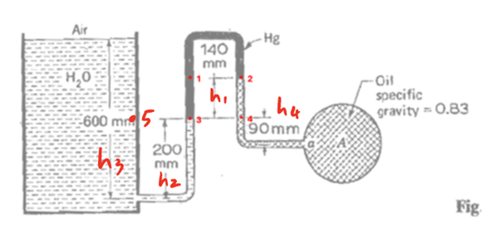

In [70]:
from PIL import Image
img = Image.open(r"figures/6_manometry_12.png")
base_width = 500  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
$p_3=p_5$  Same elevation in a continuous static fluid.

$$
p_1 + \rho_{Hg} g h_1 = \rho_{wat} g (h_3-h_2)
$$

$$
p_1 = \rho_{wat} g (h_3-h_2) - \rho_{Hg} g h_1
$$

$p_1=p_2$ Same elevation in a continuous static fluid.

$$
\rho_{wat} g (h_3-h_2) - \rho_{Hg} g h_1 = p_A - \rho_{oil} g (h_1+h_4)
$$

$$
p_A = \rho_{wat} g (h_3-h_2) - \rho_{Hg} g h_1 + \rho_{oil} g (h_1+h_4)
$$

```

In [71]:
%%render long 3

rho_Hg_= 13550 #kg/m3
h_3=600/1000 #m 
h_2=200/1000 #m 
h_1=140/1000 #m 
h_4=90/1000 #m 
s_oil= 0.83 

rho_oil=s_oil*rho_water # kg/m3
p_A= rho_water*g*(h_3-h_2)-rho_Hg_*g*h_1 +rho_oil*g*(h_1+h_4) #Pa
p_A_abs= p_A+ p_atm #Pa

<IPython.core.display.Latex object>

## Problems for Lecture 7 and 8: Forces on plane surfaces

### Force on a plane surface -uniform pressure distribution

---
#### Question 1 (**)

A force of 460 N is exerted on lever AB, as shown in the figure below. End B is connected to a piston which fits into a cylinder having a diameter of 60 mm. What force F<sub>D</sub> acts on the large piston if the volume between C and D is filled with air? {15.8 kN} 

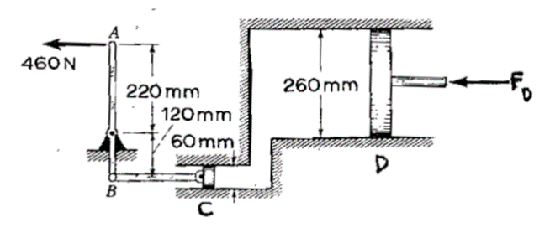

In [72]:
img = Image.open(r"figures/52.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$15.8 \; kN$

```

```{dropdown} Hint

Volume between C and D is filled with air, meaning the pressure will be uniform throughout this volume. The pressure on piston C and Piston D will be the same, but the forces will be different. 

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=2e4f2a07-5447-4318-aa2b-b2a300031ae5)
```

**Solution**

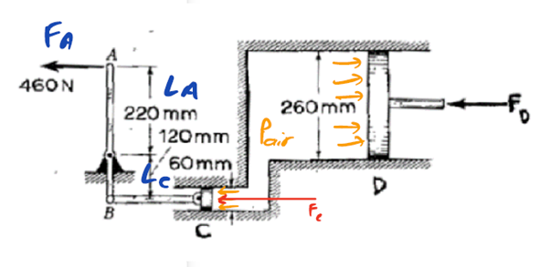

In [73]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_1.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs

$ \sum M_{Hinge}=0 $ Moment at a hinge is zero, clockwise positive

$$
F_C \cdot L_C-F_A \cdot L_A=0
$$

$$
p_{air}\cdot \frac{\pi D_C^{2}}{4} \cdot L_C=F_A \cdot L_A
$$

$$
p_{air} = \frac{4 F_A L_A}{L_C \pi D_C^{2}}
$$

$\sum F_D = 0$ NI

$$
p_{air}A_D-F_D =0
$$
```

In [74]:
%%render long 2
F_A=460 #N
D_C=0.06 #m
D_D=0.26 #m
L_A=0.22 #m
L_C=0.12 #m
p_air = 4*F_A*L_A/(L_C*pi*D_C**2) #pa
F_D = p_air*pi*D_D**2/4 #N

<IPython.core.display.Latex object>

---
#### Question 2 (**)

For the configuration shown below, calculate the weight of the piston if the gauge pressure reading is 70 kPa.

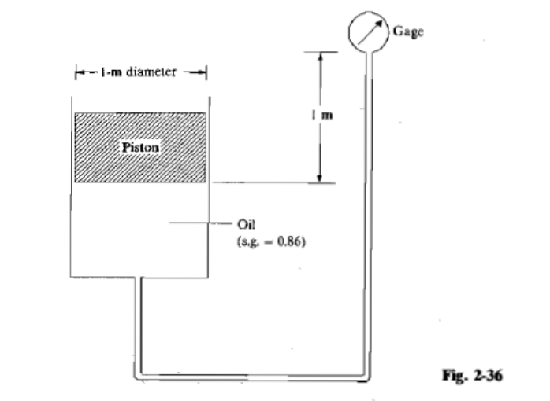

In [75]:
img = Image.open(r"figures/53.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$61.6\; kN$

```

```{dropdown} Hint

The piston is in equilibrium, meaning the weight of the piston and the force of the oil are balanced. 

Select two points at the same elevation within a continuous fluid (oil). 

Use the gauge pressure.

Equate the pressure at those two points.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=8a1ce460-b13e-493f-8c5e-b2a30002fd3e)
```

**Solution**

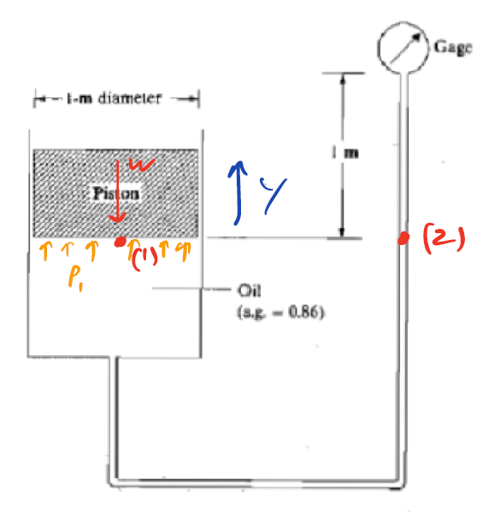

In [76]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_2.png")
base_width = 500  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs

$ \sum {F_{y,piston}}=0 $   NI

$$
-W + p_1 A_p = 0
$$  

$$
p_1 = \frac{W}{A_p}
$$

$p_1 = p_2$ Same elevation in a continuous, static fluid

$$
\frac{W}{A_p} = p_g + \rho g h_{oil}
$$

$$
W=(p_g + \rho g h_{oil}) A_p
$$
```

In [77]:
%%render long 2
p_gauge= 70000 #Pa
h_m=1 #m
S_oil=0.86 
d=1 #m
A= pi*d**2/4 #m2
rho_oil= S_oil*rho_water #kg/m3
W= (p_gauge+rho_oil*g*h_m)*A #N
W_ = W/1000 #kN

<IPython.core.display.Latex object>

### Hydrostatic force on a vertical plane surface 

---
#### Question 3 (*)[R]

A rectangular plate submerged vertically in water is 5 by 4 m, the 5-m side being horizontal and the 4-m side vertical. Determine the magnitude of the force on one side of the plate and the depth to its centre of action if the top edge of the plate is a) at the water surface and b) 1 m below the water surface. Test your answer using the ‘volume under the pressure distribution’. {392 kN at 2.67 m; 589 kN at 3.44 m}

```{dropdown} Answer

$a) \; 392 \; kN \; at \; 2.67 \; m$

$b) \; 589 \; kN \; at \; 3.44 \; m$

```

**Question 3 a)**

```{dropdown} Hint

Produce a schematic drawing of the problem showing the surface side-on. Add the following to the drawing:
- Y-axis along the surface with its origin at the water surface.
- The pressure distribution on the surface.
- The resultant hydrostatic force vector.
- Positions $Y_c$ and $Y_p$ on the Y-axis.

Note that $Y_c$ is the distance to the centroid of the surface, not the pressure distribution.

Determine the depth at the centroid $h_c$.

Calculate the size of the pressure force using the derived formula.

Calculate the second moment of area for the surface (see information sheet for formulae).

Calculate $Y_p$ using the derived formula.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=9ea660ab-0c6f-4b48-a163-b2a30002e9fa)
```

**Solution**

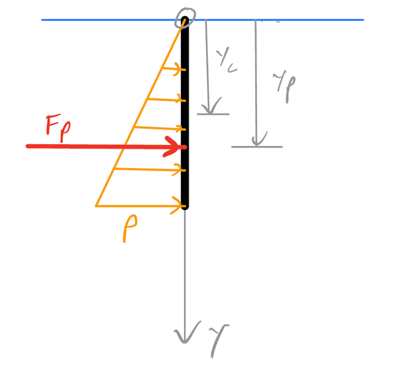

In [78]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_3a.png")
base_width = 400  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [79]:
%%render long 2
b= 5 #m
h= 4 #m
y_c= h/2 #m
h_c= y_c #m
A= b*h #m2
F= (rho_water*g*h_c*A)/1000 #kN
I_c= (b*h**3)/12 #m4
y_p= (A*y_c**2+I_c)/(y_c*A) #m

<IPython.core.display.Latex object>

**Question 3 b)**

```{dropdown} Hint
In this scenario, the pressure at the top of the plate is not zero because there is water above it. This pressure must be included in the calculation of the total force

Produce a schematic drawing of the problem showing the surface side-on. Add the following to the drawing:
- Y-axis along the surface with its origin at the water surface.
- The pressure distribution on the surface.
- The resultant hydrostatic force vector.
- Positions $Y_c$ and $Y_p$ on the Y-axis.

Note that $Y_c$ is the distance to the centroid of the surface, not the pressure distribution.

Determine the depth at the centroid $h_c$.

Calculate the size of the pressure force using the derived formula.

Calculate the second moment of area for the surface (see information sheet for formulae).

Calculate $Y_p$ using the derived formula.
```

**Solution**

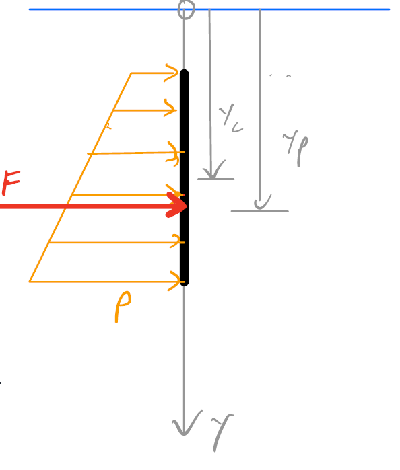

In [80]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_3b.png")
base_width = 400  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [81]:
%%render long 2
y_top=1 #m
y_c= h/2+y_top #m
h_c = y_c #m
F= (rho_water*g*h_c*A)/1000 #kN
y_p= (A*y_c**2+I_c)/(y_c*A) #m

<IPython.core.display.Latex object>

---
#### Question 4 (*)

A vertical plane surface is circular with a diameter of 2 m. If its top edge is 0.5 m below the water surface, find the magnitude of the force on one side of the surface and the depth at which it acts. {46.2 kN at 1.67 m}

```{dropdown} Answer

$46.2 \; kN \; at \; 1.67 \; m$

```

```{dropdown} Hint
Produce a schematic drawing of the problem showing the surface side-on. Add the following to the drawing:
- Y-axis along the surface with its origin at the water surface.
- The pressure distribution on the surface.
- The resultant hydrostatic force vector.
- Positions $Y_c$ and $Y_p$ on the Y-axis.

Note that $Y_c$ is the distance to the centroid of the surface, not the pressure distribution.

Determine the depth at the centroid $h_c$.

Calculate the size of the pressure force using the derived formula.

Calculate the second moment of area for the surface (see information sheet for formulae).

Calculate $Y_p$ using the derived formula.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=6be34cb4-1588-47a5-a442-b2a30002d53f)
```

**Solution**

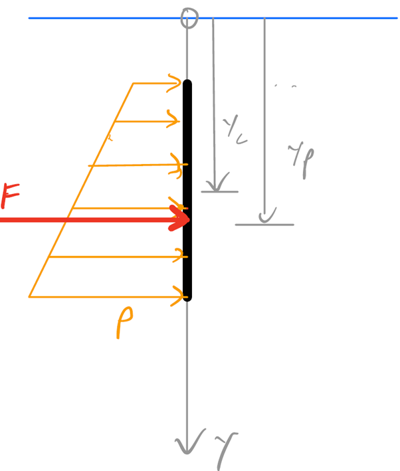

In [82]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_4.png")
base_width = 400 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [83]:
%%render long 2
d=2 #m 
y_top=0.5 #m 
y_c =y_top+d/2 #m
h_c = y_c #m
A = pi*d**2/4 #m2
F = rho_water*g*h_c*A #N


I_c=pi*(d/2)**4/4 #m4
y_p = (A * y_c**2 + I_c) / (A * y_c) #m

<IPython.core.display.Latex object>

---
#### Question 5 (***)

A water tank is pressurized to 85 cm Hg as shown below. Determine the size of the hydrostatic force per meter width on panel AB, as well as its centre of pressure.

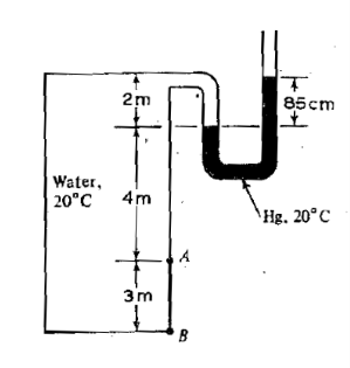

In [84]:
img = Image.open(r"figures/56.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$502 \; kN \; at \; 17.1 \; m$

```

```{dropdown} Hint

Calculate the pressure head at the top of the tank.

Show the equivalent water level on the figure (draw a piezometer on the top of the tank).

Then solve problem like open surface problems.

Produce a schematic drawing of the problem showing the surface side-on. Add the following to the drawing:
- Y-axis along the surface with its origin at the water surface.
- The pressure distribution on the surface.
- The resultant hydrostatic force vector.
- Positions $Y_c$ and $Y_p$ on the Y-axis.

Note that $Y_c$ is the distance to the centroid of the surface, not the pressure distribution.

Determine the depth at the centroid $h_c$.

Calculate the size of the pressure force using the derived formula.

Calculate the second moment of area for the surface (see information sheet for formulae).

Calculate $Y_p$ using the derived formula.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=bfd792c2-4548-4721-829b-b2a30002b714)
```


**Solution**

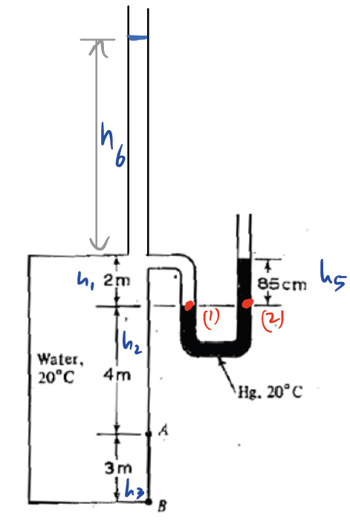

In [85]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_5_1.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} 
$ p_1 = p_2 $ Same elevation in a continuous, static fluid

$$
\rho g (h_6+h_1) = \rho_{Hg} g h_{Hg}
$$

$$
\rho (h_6+h_1) = \rho_{Hg} h_{Hg}
$$

$$
h_6 = \frac{\rho_{Hg} h_{Hg}}{\rho}-h_1
$$

```

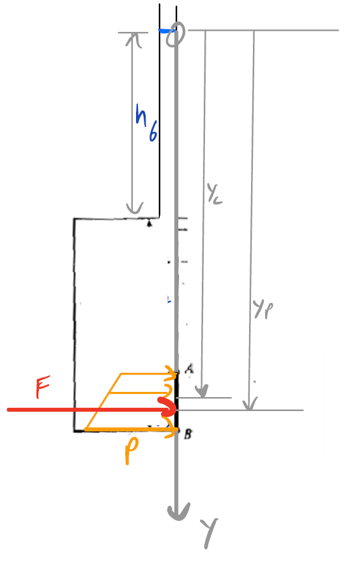

In [86]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_5_2.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [87]:
%%render long 1
p= 85 #cm Hg
h_1= 2#m
h_2= 4 #m
h_3= 3 #m
h_5= 0.85 #m
b= 1 #m
h_6 = rho_Hg*h_5/rho_water - h_1 #m
y_c = h_6+h_1+h_2+h_3/2 #m
h_c = y_c #m
A = h_3*b #m2
F = rho_water*g*h_c*A #N
I_c = b*h_3**3/12 #m4
y_p = (A * y_c**2 + I_c) / (A * y_c) #m

<IPython.core.display.Latex object>

### Hydrostatic force on a plane surface 

---
#### Question 6 (*)


A flat plate is used to close a rectangular opening in a large water tank as shown below. The plate is 3 m wide and 4 m long. What is the magnitude and position of the resultant force of the water on the plate?

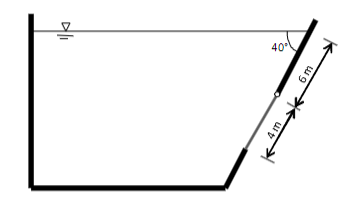

In [88]:
from PIL import Image
img = Image.open(r"figures/57.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$605.4 \; kN \; at \; 8.166 \; m $ from the water surface along the wall. 

```

```{dropdown} Hint
The pressure distribution is perpendicular to the plate and increases with depth. The height of the centroid takes into account both the height above the plate and the centroid of the plate itself. 

Produce a schematic drawing of the problem showing the surface side-on. Add the following to the drawing:
- Y-axis along the surface with its origin at the water surface.
- The pressure distribution on the surface.
- The resultant hydrostatic force vector.
- Positions $Y_c$ and $Y_p$ on the Y-axis.

Note that $Y_c$ is the distance to the centroid of the surface, not the pressure distribution.

Determine the depth at the centroid $h_c$.

Calculate the size of the pressure force using the derived formula.

Calculate the second moment of area for the surface (see information sheet for formulae).

Calculate $Y_p$ using the derived formula.


[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=8467cecb-8bf9-45ff-ad0a-b2a30002b04a)
```


**Solution**

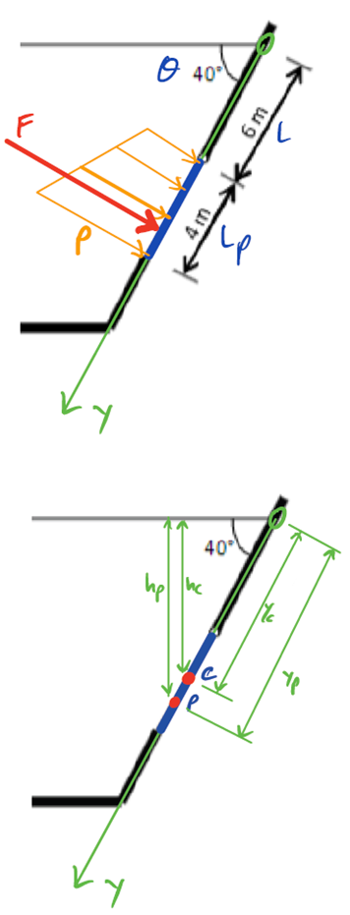

In [89]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_6.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [90]:
%%render long 2
B=3 #m
L_p=4 #m
theta=40 #°
L=6 #m
y_c= L+L_p/2 #m
h_c = y_c*sin(radians(theta)) #c
A = B*L_p #m2
F_= rho_water*g*h_c*A #N
I_c = (B*L_p**3)/12 #m4
y_p = (A * y_c**2 + I_c) / (A * y_c) #m

<IPython.core.display.Latex object>

---
#### Question 7 (*)

A section through a container holding water is shown below. One of the container’s panels is angled at 55° to the horizon and contains a circular gate with a diameter of 2 m. The water is 4 m deep at the top of the gate.  Calculate the size of the resultant force of the water on the gate, as well as its centre of pressure.

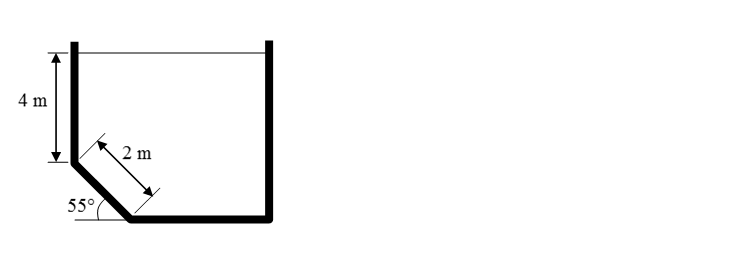

In [91]:
img = Image.open(r"figures/58.png")
img

```{dropdown} Answer
$148.52 \; kN; \; 5.93 \;m $ 

```

```{dropdown} Hint
Produce a schematic drawing of the problem showing the surface side-on. Add the following to the drawing:
- Y-axis along the surface with its origin at the water surface.
- The pressure distribution on the surface.
- The resultant hydrostatic force vector.
- Positions $Y_c$ and $Y_p$ on the Y-axis.

Note that $Y_c$ is the distance to the centroid of the surface, not the pressure distribution.

Determine the depth at the centroid $h_c$.

Calculate the size of the pressure force using the derived formula.

Calculate the second moment of area for the surface (see information sheet for formulae).

Calculate $Y_p$ using the derived formula.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=54cdbd1a-6874-4480-bb32-b2a30002a36f)
```


**Solution**

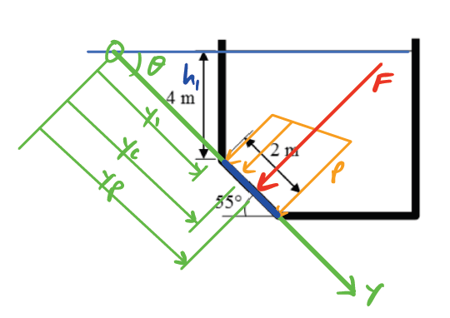

In [92]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_7.png")
base_width = 450  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [93]:
%%render long 2
h_1=4 #m
d=2 #m
theta=55 #°
y_1 = h_1/sin(radians(theta)) #m
y_c = y_1+d/2 #m
h_c = y_c*sin(radians(theta)) #m
A= pi*(d/2)**2 #m2
F= rho_water*g*h_c*A/1000 #kN

I_c= (pi*(d/2)**4)/4 #m4
y_p= (A*y_c**2+I_c)/(y_c*A) #m

<IPython.core.display.Latex object>

---
#### Question 8 (*)

The container shown in the figure below has a width of 5 m into the screen and is filled with water. A panel BC with cross-sectional shape as shown is installed in one wall. The distances AB and BC are 4 m and 2 m respectively, and the angle θ is 135°. Calculate the resultant force of the water on panel BC and its centre of pressure.

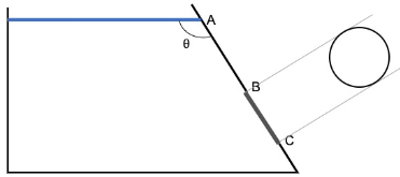

In [94]:
from PIL import Image
img = Image.open(r"figures/59.png")
base_width = 400  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
$108.96 \; kN; \; 5.05 \;m $ 
```

```{dropdown} Hint
Produce a schematic drawing of the problem showing the surface side-on. Add the following to the drawing:
- Y-axis along the surface with its origin at the water surface.
- The pressure distribution on the surface.
- The resultant hydrostatic force vector.
- Positions $Y_c$ and $Y_p$ on the Y-axis.

Note that $Y_c$ is the distance to the centroid of the surface, not the pressure distribution.

Determine the depth at the centroid $h_c$.

Calculate the size of the pressure force using the derived formula.

Calculate the second moment of area for the surface (see information sheet for formulae).

Calculate $Y_p$ using the derived formula.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=e5724522-8f2f-40e2-94c6-b2a300029f50)
```


**Solution**

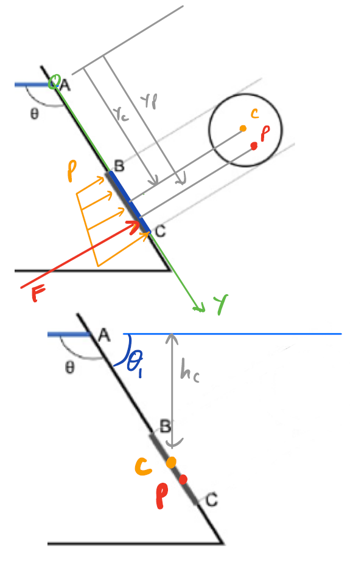

In [95]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_8.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [96]:
%%render long 2
B=5 #m 
AB= 4#m
BC= 2#m 
theta = 135 #°
theta_1 = 180 - theta #°
y_c = AB+BC/2 #m
A = pi*(BC**2)/4 #m2
h_c = y_c*sin(radians(theta_1)) #m
F = rho_water*g*h_c*A #N
r = BC/2 #m
I_c = pi*r**4/4 #m4
y_p= (A*y_c**2+I_c)/(y_c*A) #m

<IPython.core.display.Latex object>

---
#### Question 9 (*)[R]

The container shown in the figure below has a width of 5 m into the page and is filled with water. A panel BC with cross-sectional shape as shown is installed in one wall. The distances AB and BC are 4 m and 2 m respectively, b is 2 m and the angle θ is 135°. Calculate the resultant force of the water on panel BC and its centre of pressure.  

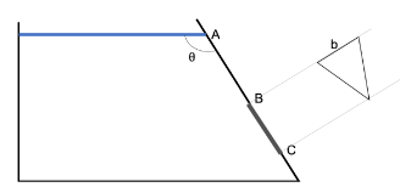

In [97]:
img = Image.open(r"figures/60.png")
base_width = 400  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
$64.7 \; kN; \; 4.71 \;m $
```

```{dropdown} Hint
Produce a schematic drawing of the problem showing the surface side-on. Add the following to the drawing:
- Y-axis along the surface with its origin at the water surface.
- The pressure distribution on the surface.
- The resultant hydrostatic force vector.
- Positions $Y_c$ and $Y_p$ on the Y-axis.

Note that $Y_c$ is the distance to the centroid of the surface, not the pressure distribution.

Determine the depth at the centroid $h_c$.

Calculate the size of the pressure force using the derived formula.

Calculate the second moment of area for the surface (see information sheet for formulae).

Calculate $Y_p$ using the derived formula.

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=e38dd203-de30-44ba-9f2a-b2a300029ab7)
```


**Solution**

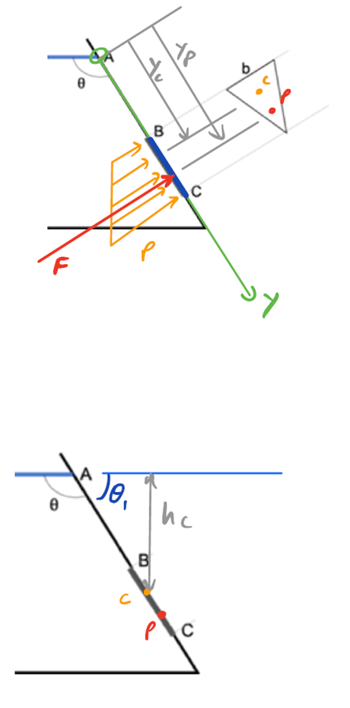

In [98]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_9.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [99]:
%%render long 2
AB=4 #m
BC=2 #m
b = 2 #m
theta=135 #°
theta_1 = 180 - theta #°
y_c = AB+BC/3 #m
A= b*BC/2 #m2
h_c = y_c*sin(radians(theta_1)) #m
F = rho_water*g*h_c*A #N
I_c = b*BC**3/36 #m4
y_p= (A*y_c**2+I_c)/(y_c*A) #m


<IPython.core.display.Latex object>

---
#### Question 10 (*)

The container shown in the figure below has a width of 5 m into the screen and is filled with water. A panel BC with cross-sectional shape as shown is installed in one wall. The distances AB and BC are 3 m and 1 m respectively, and the angle θ is 120°. Calculate the resultant force of the water on panel BC and its centre of pressure.

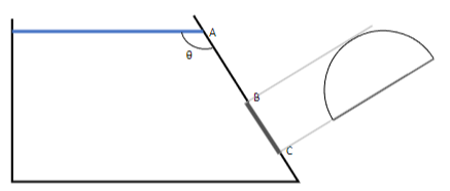

In [100]:
from PIL import Image
img = Image.open(r"figures/61.png")
base_width = 450  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
$47.72 \; kN; \; 3.6 \;m $
```

```{dropdown} Hint
Produce a schematic drawing of the problem showing the surface side-on. Add the following to the drawing:
- Y-axis along the surface with its origin at the water surface.
- The pressure distribution on the surface.
- The resultant hydrostatic force vector.
- Positions $Y_c$ and $Y_p$ on the Y-axis.

Note that $Y_c$ is the distance to the centroid of the surface, not the pressure distribution.

Determine the depth at the centroid $h_c$.

Calculate the size of the pressure force using the derived formula.

Calculate the second moment of area for the surface (see information sheet for formulae).

Calculate $Y_p$ using the derived formula.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=46c5cb97-6239-48b4-802a-b2a3000296e9)
```


**Solution**

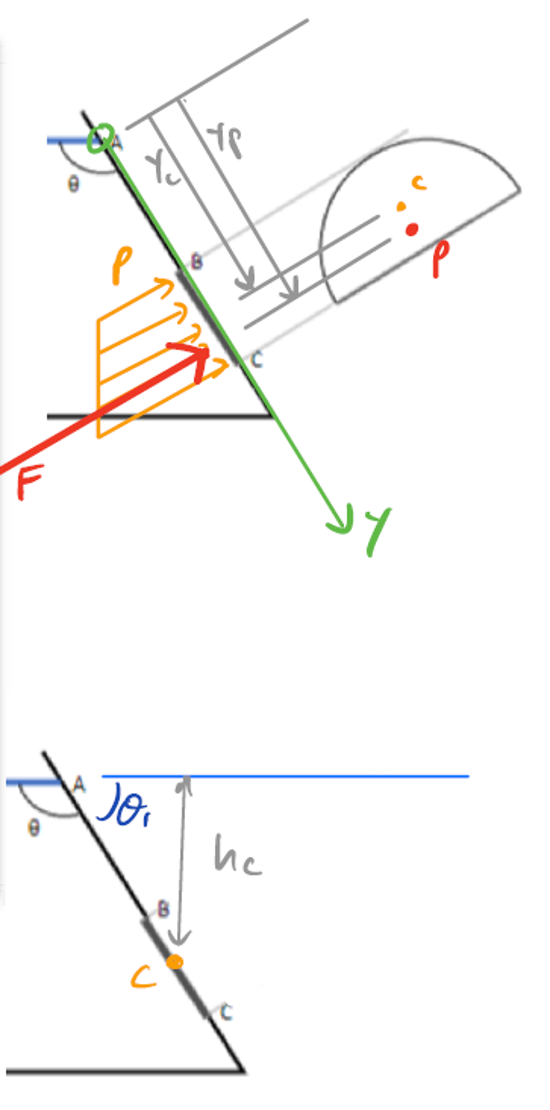

In [101]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_10.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [102]:
%%render long 2
AB= 3#m
BC= 1#m 
theta = 120 #°
theta_1 = 180 - theta #°
y_c= AB+BC-4*BC/(3*pi) #m
A= pi*BC**2/2 #m2
h_c = y_c*sin(radians(theta_1)) #m
F = rho_water*g*h_c*A #N

I = 0.1098*BC**4 #m4
y_p= (A*y_c**2+I)/(y_c*A) #m

<IPython.core.display.Latex object>

---
#### Question 11 (**)[R]

 A 60 cm square gate has its top edge 12 m below the water surface. It is on a 45° angle and its bottom edge is hinged as shown below. What force P is needed to just open the gate?

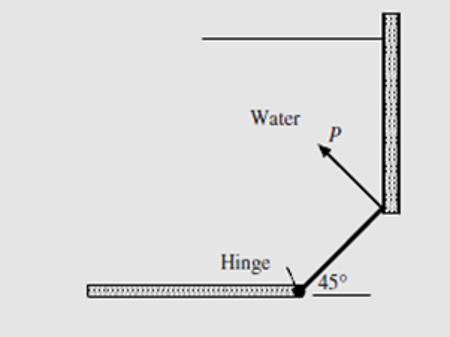

In [103]:
img = Image.open(r"figures/62.png")
base_width = 450  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
$21.42 \; kN$
```

```{dropdown} Hint
Calculate the size and action point of the hydrostatic force on the gate.

Take moments around the hinge to calculate the opening force.

Produce a schematic drawing of the problem showing the surface side-on. Add the following to the drawing:
- Y-axis along the surface with its origin at the water surface.
- The pressure distribution on the surface.
- The resultant hydrostatic force vector.
- Positions $Y_c$ and $Y_p$ on the Y-axis.

Note that $Y_c$ is the distance to the centroid of the surface, not the pressure distribution.

Determine the depth at the centroid $h_c$.

Calculate the size of the pressure force using the derived formula.

Calculate the second moment of area for the surface (see information sheet for formulae).

Calculate $Y_p$ using the derived formula.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=d2e14f52-c888-4922-93ec-b2a300029415)
```


**Solution**

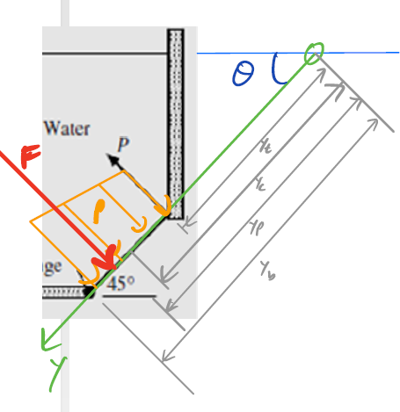

In [104]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_11_a.png")
base_width = 400  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

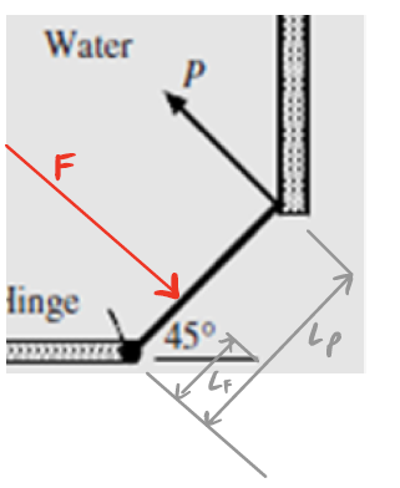

In [105]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_11_b.png")
base_width = 400  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell output
Moment balance in the hinge

$$
\sum M = 0 $$ 


$$
F_p \cdot L_p= F \cdot L_F\\
$$


$$
F_p =\frac{F L_F}{L_p}
$$
```


In [106]:
%%render long 2

theta=45 #°
h_t = 12 #m
b = 0.6 #m
y_t = h_t/sin(radians(theta)) #m
y_c = y_t +b/2 #m
y_b = y_t +b#m
h_c = y_c*sin(radians(theta))
A = b**2 #m2
F = rho_water*g*h_c*A #N
I_c = b**4/12 #m4
y_p= (A*y_c**2+I_c)/(y_c*A) #m
L_p = y_b - y_t #m
L_F = y_b - y_p #m
F_p = F*L_F/L_p #N

<IPython.core.display.Latex object>

---
#### Question 12 (***)

The figure below shows a plane pivot gate installed on a concrete dam. The gate is shown in its closed position. The vertical member (AB) has a length of L<sub>AB</sub> = 3.0 m. The horizontal member (BC) has a length L<sub>BC</sub> = 1.5 m. The width of the gate (into the paper) is lp = 10 m. The water level in the reservoir is located at a depth h above the gate’s pivot point (B). When the gate is in its closed position (as shown in the sketch), the gate seals watertight along C. At what depth h will the gate just start to open?

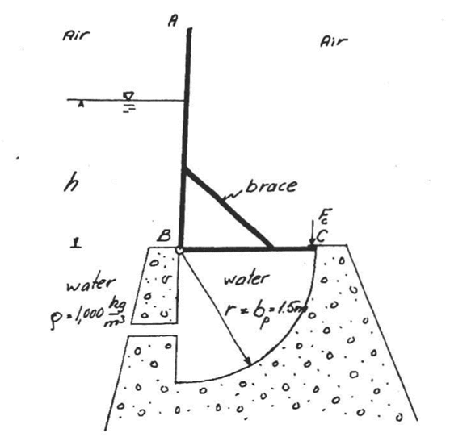

In [107]:
from PIL import Image
img = Image.open(r"figures/63.png")
base_width = 450  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
$2.6 \; m$
```

```{dropdown} Hint
Take the moment balance about the pivot point B, which includes the forces from the vertical (AB) and horizontal (BC) members of the gate.

Produce a schematic drawing of the problem showing the surface side-on. Add the following to the drawing:
- Y-axis along the surface with its origin at the water surface.
- The pressure distribution on the surface.
- The resultant hydrostatic force vector.
- Positions $Y_c$ and $Y_p$ on the Y-axis.

Note that $Y_c$ is the distance to the centroid of the surface, not the pressure distribution.

Determine the depth at the centroid $h_c$.

Calculate the size of the pressure force using the derived formula.

Calculate the second moment of area for the surface (see information sheet for formulae).

Calculate $Y_p$ using the derived formula.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=bbc854be-f97b-48b1-8750-b2a300029192)
```


**Solution**

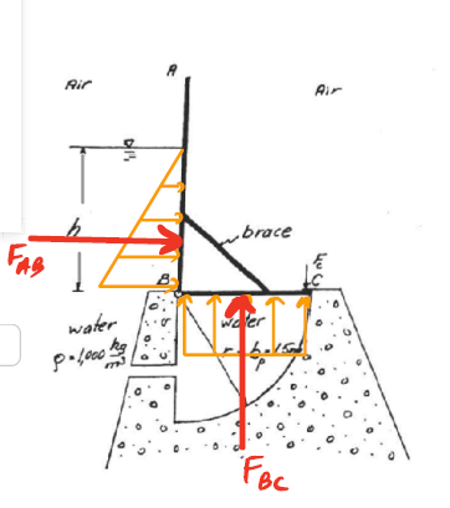

In [108]:
img = Image.open(r"figures/7&8_uniform_pressure_distribution_12_1.png")
base_width = 450  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

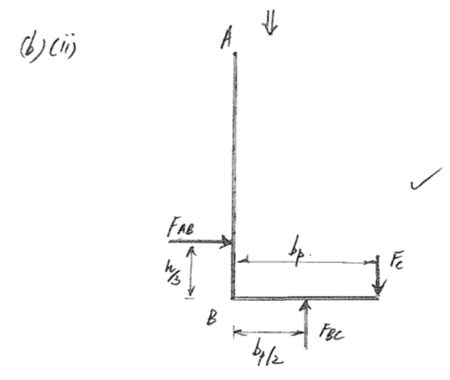

In [109]:
from PIL import Image
img = Image.open(r"figures/63S.png")
base_width = 450  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell output
Moment balance around point B 

$$
\sum M= 0\\
$$

$$
F_{AB} \cdot \frac{h}{3} - F_{BC} \cdot \frac{L_BC}{2}=0\\
$$

$$
F_{AB} = \rho_{\text{water}} g h_c A = \rho_{\text{water}} g \frac{h}{2} h b = \frac{1}{2} \rho_{\text{water}} g b h^2
$$


$$
F_{BC}= p_{BC} A = \rho g h b L_{BC}
$$


$$
\frac{\rho g h^{2} b}{2} \frac{h}{3} - \rho g h b L_{BC} \frac{L_{BC}}{2} = 0
$$

$$
\frac{\rho g h^{3} b}{6} - \rho g h b \frac{L_{BC}^{2}}{2} = 0
$$

$$
h= \sqrt {3} L_{BC}\\
$$

```

**Solution**

In [110]:
%%render long 2
L_BC = 1.5 #M
h = sqrt(3) * L_BC #m

<IPython.core.display.Latex object>

## Problems for Lecture 9: Forces on curved surfaces

### Force on a spherical container

---
#### Question 1 (**) [R]

A spherical steel tank of 15 m diameter contains gas under a pressure of 350 kPa. The tank consists of two half-spheres joined together with a weld. What is the total force on the weld? What will the tensile force across the weld be in kN/m?

```{dropdown} Answer
$61.8 \; MN \;; 1.31 \; MN/m$
```


```{dropdown} Hint
Draw a free body diagram of one half of the sphere.

Apply equilibrium.

The pressure force in the X direction is equal to the force on a projection onto a plane surface.

For the tensile force across the weld in kN/m use the perimeter of the weld.

$ \sum F_x = 0 $ NI

$$
F_{px} - F_b = 0
$$

$$
F_b = pA
$$  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=2cac29f0-8ee7-4ee4-b6fc-b2a30002868a)
```

**Solution**

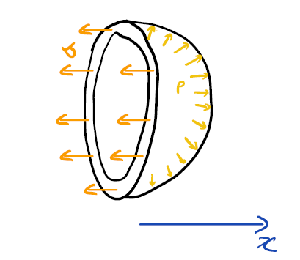

In [111]:
img = Image.open(r"figures/9_curved_1.png")
base_width = 300  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [112]:
%%render long
d=15 #m
p=350*1000 #Pa

A= pi*d**2/4 #m2

F_b = p * A #N

perimeter= pi*d #m
F_tensile= F_b/perimeter #N/m

<IPython.core.display.Latex object>

---
#### Question 2 (***)

By how much does the pressure inside a 2 mm diameter spherical water droplet exceed the pressure in the surrounding air? Work from basic principles and assume the water/air surface tension to be 0.0735 N/m.

```{dropdown} Answer
$147 \; Pa$
```

```{dropdown} Hint
Create a free-body diagram for the drop cut in half.

Add the surface tension and pressure.

Apply equilibrium.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=d522e000-f065-4cc7-890f-b2a300028524)
```

**Solution**

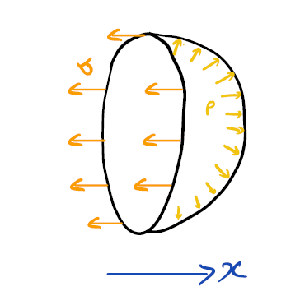

In [113]:
img = Image.open(r"figures/9_curved_2.png")
base_width = 300  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{Dropdown} Show code cell outputs

$$
\sum F_x =0 \\
F_{\sigma}-F_{px}=0\\
$$

$$
\sigma \pi D - \frac{\pi D^{2}}{4} p = 0
$$

$$
p = \frac{4*\sigma}{D}
$$
```

In [114]:
%%render long 3
d= 2/1000 #m
sigma= 0.0735 #N/m
Delta_P= 4*sigma/d #Pa

<IPython.core.display.Latex object>

---
#### Question 3 (***)

By how much does the pressure inside a 2 mm diameter air bubble in 15 °C water exceed the pressure in the surrounding water?

```{dropdown} Answer
$147 \; Pa$
```


```{Dropdown} Hint
Like a drop, there is a surface tension at the air-water interface.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=2d028833-a6d0-4183-827c-b2a3000280fd)
```

**Solution**

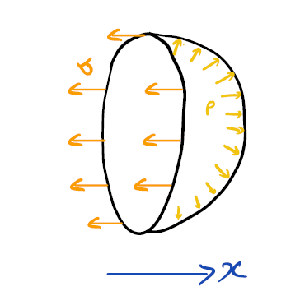

In [115]:
img = Image.open(r"figures/9_curved_2.png")
base_width = 300  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{Dropdown} Show code cell outputs

Replacing the two forces in the sum of forces:

$$
\sigma \pi d=\Delta p \frac {\pi d^2}{4}\\
\Delta p =\frac {4\sigma}{d}
$$  

In the ICAO table, the surface tension of water at 15°C is: 0.073 N/m  
```

In [116]:
%%render long
d=2/1000 #m
sigma= 0.0735 #N/m
dP= 4*sigma/d #Pa

<IPython.core.display.Latex object>

---
#### Question 4 (***)[R]

Calculate the gauge pressure inside a 50 mm diameter soap bubble from basic principles. Assume a temperature of 15°C and that the soap does not significantly change the properties of the water. 

```{dropdown} Answer
$11.8 \; Pa$
```


```{Dropdown} Hint
A soap bubble is surrounded by a thin layer of fluid. This fluid has two surfaces: one with the air inside the bubble and one with the air outside the bubble  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=db10b6ab-2fe6-4bc5-9567-b2a300026916)
```

**Solution**

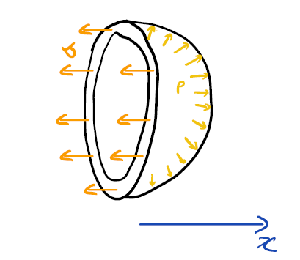

In [117]:
img = Image.open(r"figures/9_curved_1.png")
base_width = 300  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{Dropdown} Show code cell outputs

$ \sum F_x = 0 $  NI

$$
2\sigma \pi d= p \frac {\pi d^2}{4}\\
p =\frac {8\sigma}{d}
$$  

In the ICAO table, the surface tension of water at 15°C is $\sigma= 0.0735 N/m$
```

In [118]:
%%render long 2
d=50 #mm 
sigma= 0.0735 #N/m
p= 8*sigma/(d/1000) #Pa

<IPython.core.display.Latex object>

---
#### Question 5 (***)

The cylindrical tank below has a hemispherical end cap ABC. Calculate the total horizontal force exerted on ABC by the oil and water.

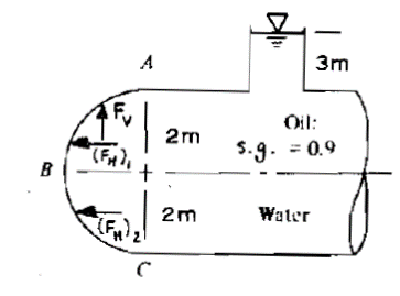

In [119]:
img = Image.open(r"figures/68.png")
base_width = 400  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
$560 \; kN$
```


```{Dropdown} Hint

The force in ABC can be expressed as the sum of the force in AB and the force in BC. Therefore, you can calculate these forces considering their respective $h_c$.  

For the force AB, $h_c$ should consider the centroid of a semicircular area and the column of oil shown in the figure.  

For the force BC, calculate the $h_c$ if the oil is replaced by an equivalent water depth.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=41913641-6c95-41ea-b6db-b2a300026912)

```


**Solution**

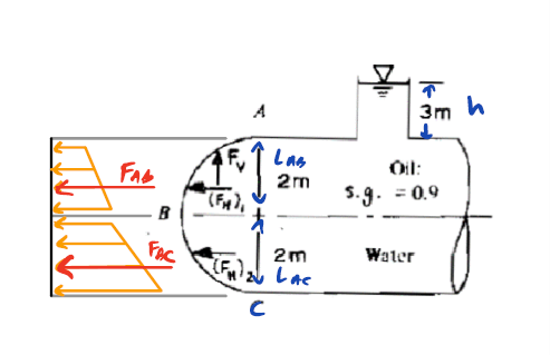

In [120]:
img = Image.open(r"figures/9_curved_5.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [121]:
%%render long
L_AB= 2 #m
L_BC= 2 #m
s_oil= 0.9
h= 3 #m
rho_oil= s_oil*rho_water #kg/m3
r= 2#m
h_c_AB= h+r-(4*r)/(3*pi) #m
A= (pi*r**2)/2 #m2
F_AB= rho_oil*g*h_c_AB*A #N

p_B = rho_oil*g*(r+h) #pa

h_wat_equivalent = p_B/(rho_water*g) #m

h_c_BC = h_wat_equivalent+4*r/(3*pi) #m

F_BC = rho_water*g*h_c_BC*A

F_ABC= F_AB+F_BC #N

<IPython.core.display.Latex object>

---
#### Question 6 (** - ***)[R]

The rectangular tank shown below has a width of 3 m into the page and a maximum water depth of 6 m. One of the bottom edges of the tank consists of a curved panel with a radius of 1 m. 

   a.**Calculate the size and line of action of the horizontal hydrostatic force on the curved panel. 

   b.**Calculate the size of the vertical hydrostatic force on the curved panel. 

   c.***Calculate the line of action of the vertical hydrostatic force on the curved panel. 

   d.**Calculate the size and line of action of the resultant hydrostatic force exerted on the curved panel. 

   e.***Show that the resultant hydrostatic force acts perpendicularly on the curved panel.


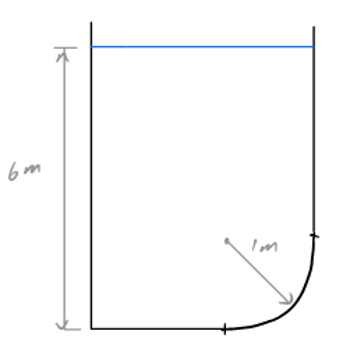

In [122]:
from PIL import Image
img = Image.open(r"figures/69.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

a)  $161.9 \; kN$  acting 5.515 m from the water surface  

b)  $170.3 \; kN$  

c) $0.510 \; m$ from right tank edge  

d) $234.93 \; kN$ acting at 43.55° from the vertical
```

**Question 6 (a)**

```{Dropdown} Hint

The horizontal force is calculated as force on a projection of the panel on a plane surface. 

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=fff6bd90-17ad-46b6-92d2-b2a30002690b)
```

**Solution**

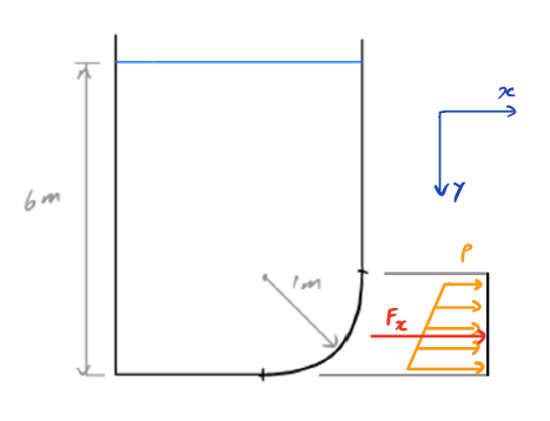

In [123]:
img = Image.open(r"figures/9_curved_6_a.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [124]:
%%render long 2
B=3 #m
h=6#m 
r=1#m
h_c= h-r/2 #m
A = B*r
F_x= rho_water*g*h_c*A/1000 #kN
I_c= B*r**3/12 #m4
y_p= h_c+I_c/(h_c*A)#m

<IPython.core.display.Latex object>

**Question 6 (b)**

```{Dropdown} Hint
$$
w_1 = \rho g V_1 = \rho g B(h-r)
$$

$$
w_2 = \rho g V_2 = \rho g B \frac{\pi r^{2}}{4}
$$
```

**Solution**

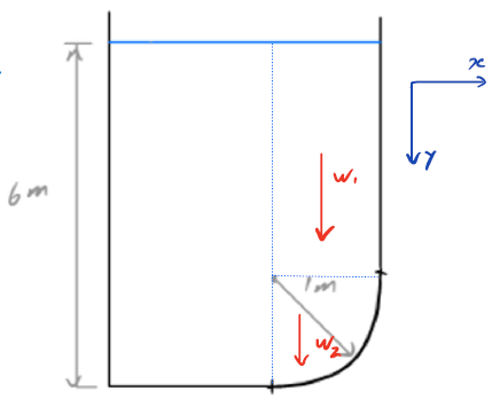

In [125]:
img = Image.open(r"figures/9_curved_6_b.png")
base_width = 500  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [126]:
%%render long 2
W_1 = rho_water*g*B*(h-r) #N
W_2 = rho_water*g*B*pi*r**2/4 #N
W = (W_1+W_2)/1000 #kN

<IPython.core.display.Latex object>

**Question 6 (c)**

```{Dropdown} Hint
The line of action of the vertical force goes through the centroid of the fluid above the plate. 

Calculate centroid separately for rectangular and quarter-circular shapes and then calculate the equivalent.
```

**Solution**

```{dropdown} Show code cell outputs

Moments around 0:

$$
M_W = M_{W_1} + M_{W_2}
$$

$$
W \Delta x = W_1 \Delta x_1 +  W_2 \Delta x_2 
$$

$$
\Delta x = \frac{W_1 \Delta x_1 +  W_2 \Delta x_2 }{W}
$$
```

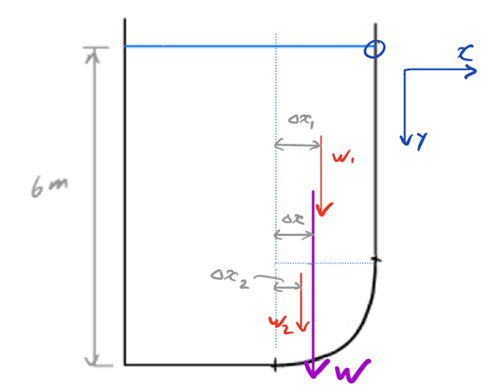

In [127]:
img = Image.open(r"figures/9_curved_6_c.png")
base_width = 500  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [128]:
%%render long 2
A_2= pi*r**2/4 #m2
A_1= (h-r)*r #m2
Delta_X_2= 4*r/(3*pi)#m
Delta_X_1= r/2 #m
Delta_X = (W_1*Delta_X_1 + W_2*Delta_X_2)/W #m


<IPython.core.display.Latex object>

**Question 6 (d)**

**Solution**

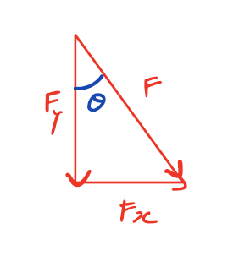

In [129]:
img = Image.open(r"figures/9_curved_6_d.png")
base_width = 250  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

In [130]:
%%render long 2
F_r= sqrt(F_x**2+ W**2) #kN
theta= degrees(atan(F_x/W)) #°

<IPython.core.display.Latex object>

**Question 6 (e)**

```{Dropdown} Hint
If the hydrostatic force vector is in line with (will go through) the center of the curve, it has to be perpendicular to the surface (just like the radius is).

Determine the action point of the hydrostatic force.

Calculate the direction of a line between the center and action points.

Compare the direction to that of the hydrostatic force.
```

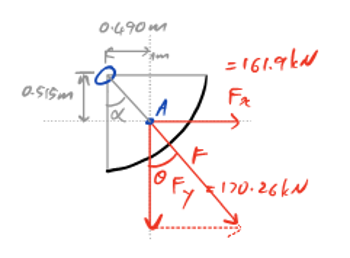

In [131]:
from PIL import Image
img = Image.open(r"figures/69S.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

**Solution**

In [132]:
%%render long 2
X_O= Delta_X #m
Y_O= y_p-h+r#m
alpha= degrees(atan(X_O/Y_O)) #°

<IPython.core.display.Latex object>

### COMBINED PROBLEMS

---
#### Question 7 (***)

Two identical rigid cylinders with one end open are used in an experiment. Each cylinder has an internal diameter of 20 mm and an internal length of 10 m. The cylinders are placed upright with their open ends at the top under standard sea level conditions as shown in the diagram. Cylinder A is left empty, while cylinder B is completely filled with water. A perfectly sealing frictionless piston is then inserted into each cylinder and loaded with weights to a total mass (including the piston) of 200 kg. Assume the specific constant of air Rs = 287 J/kgK. Determine the following for each cylinder:  

a) The internal pressure at the top of the cylinder (just below the piston).
b) The equilibrium height of the piston above the floor. Assume that the temperature of the water and gas do not change due to the compression.
c) The circumferential stress in the air cylinder wall. Assume a cylinder wall thickness of 20 mm and work from basic principles.


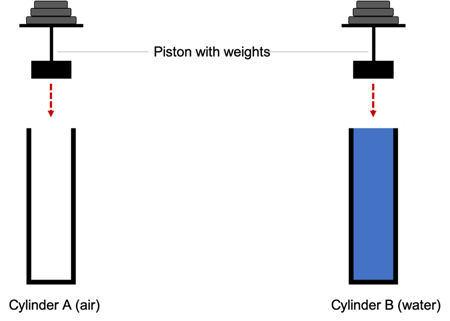

In [133]:
img = Image.open(r"figures/70.png")
base_width = 450  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

a)  $6.245 \; MPa$  

b)  $160 \; mm \; 9.971 \;m$  

c) $3.123 \; MPa$ 
```

**Question 7 (a)**

```{Dropdown} Hint
The internal pressure at the top of the cylinder is calculated the same way in cylinder A and B.

Draw a free body diagram of the piston and apply equilibrium.  

[Click here for a video explaining the problem](https://auckland.au.panopto.com/Panopto/Pages/Viewer.aspx?id=da7b4d9e-73ba-4286-be4a-b2a300026974)
```

**Solution**

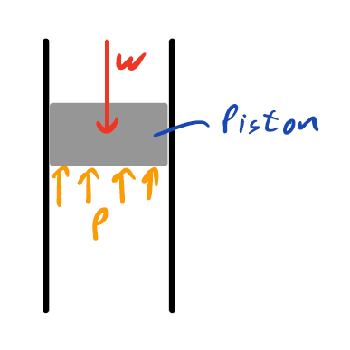

In [134]:
img = Image.open(r"figures/9_curved_7_a.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{Dropdown} Show code cell outputs  

$$
\sum F_y=0\\
$$

$$
W -F_p=0\\
$$

$$
W= pA
$$

$$
p=W/A
$$  
```

In [135]:
%%render long 4
d= 20/1000 #m
L= 10 #m
m= 200 #kg
R_s= 287 #J/kgK
W= m*g #N
A= pi*(d/2)**2 #m2
p= W/A #Pa

<IPython.core.display.Latex object>

**Question 7 (b)**

```{Dropdown} Hint
In this problem, both the air (cylinder A) and the water (cylinder B) will be compressed and the weigth of the cylinder must be balanced by the force exerted by the fluid.  

In the case of cylinder A, the gas compression can be calculated with the perfect gas law , where temperature is the same and the volume reduces.  

In the case of cylinder B, the compressibiity of water can be calculated with the bulk modulus equation.
```

**Solution**

```{Dropdown} Show code cell outputs
**Cylinder A:**

$$
\frac{p}{\rho}=R_s T
$$

Assuming no change in T:

$$
\frac{p_1}{\rho_1}=\frac{p_2}{\rho_2}\\
\rho_2=p_2 \frac{\rho_1}{p_1}
$$  

From the ICAO standard atmosphere table, $\rho_1=1.225 kg/m^3$ and $p_1=101325 Pa$

From conservation of mass:

$$
\rho_1 Vol_1 =\rho_2 Vol_2\\
\rho_1 \cdot A \cdot L_1 =\rho_2 \cdot A \cdot L_2
$$

Solving for $L_2$:  

$$
L_2=  \frac{\rho_1 L_1}{\rho_2}
$$  
  
     
    

**Cylinder B:**

Considering:

$$
-\Delta p= E_v \frac{\Delta v}{v}\\
v= 1/\rho_{water}
$$

and, From the table of the physical properties of common liquids at standard sea-level atmospheric conditions at 15°C, $E_v= 2.14*10^9 Pa$  

$\Delta v$ can be solved.  
Then, considering that:

$$ 
v_2=v+\Delta v\\
\rho_2=\frac{1}{v_2}
$$  

and from conservation of mass:

$$
\rho_1 \cdot Vol_1 =\rho_2 \cdot Vol_2\\
\rho_1 \cdot A \cdot L_1 =\rho_2 \cdot AL2
$$

$L_2$ can be calculated as:  

$$
L_2=  \frac{\rho_1 L_1}{\rho_2}
$$  
```

In [136]:
%%render long 3
rho_1A=1.225 #kg/m3
p_1A=101325 #Pa

p_2A= p_1A+p #Pa
rho_2A= p_2A*rho_1A/p_1A #kg/m3

L_1= L #m
L_2A= rho_1A*L_1/rho_2A #m

E_vB=2.14*10**9 #Pa

v_B= 1/rho_water #m3/kg

dv_B= -p/E_vB*v_B #m3
v_2B=v_B +dv_B #m3

rho_2B= 1/v_2B #kg/m3

L_2B= rho_water*L_1/rho_2B #m

<IPython.core.display.Latex object>

**Question 7 (c)**

```{Dropdown} Hint
Pressure in teh air cylinder is uniform.

Take a length-wise section through the cylinder and create a free-body diagram.
```

**Solution**

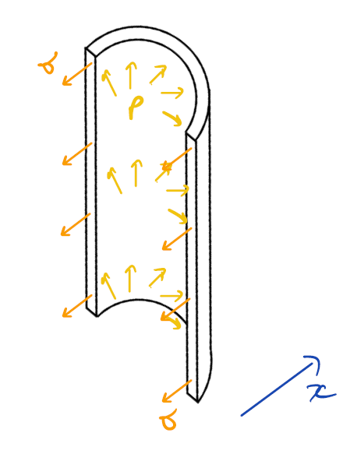

In [137]:
img = Image.open(r"figures/9_curved_7_c.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{Dropdown} Show code cell outputs

$$
\sum F_x=0\\
$$

$$
pdL=2 \sigma Lt
$$

Solving for $\sigma$:

$$\sigma= \frac{pd}{2t}$$
```

In [138]:
%%render long 2
t=20/1000 #m
sigma= p*d/(2*t)/1000000 #MPa

<IPython.core.display.Latex object>

## Problems for Lecture 10: Buoyancy 

### Basic Buoyancy Problems

#### Question 1 (*)[R]

What is the weight of the loaded barge below? The barge is 7 m in width.

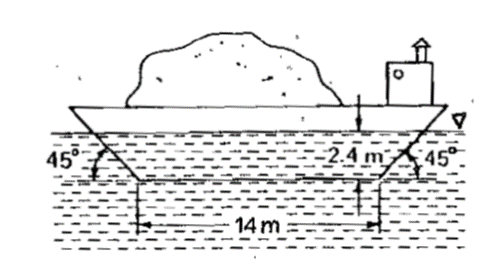

In [140]:
img = Image.open(r"figures/71.png")
img

```{dropdown} Answer


```
$2703 \; kN$

```{Dropdown} Hint

```
By doing the sum of force in the y axis, the weight of the loaded barge can be calculated

$$
\sum F_y=0\\
F_b-W=0\\
$$

$$
F_b=W\\
\rho \cdot  g \cdot  Vol = W
$$

Where the volume is the sum of the rectangle plus the two lateral triangles.

$$
Vol= b_{rec} \cdot h_{rec} \cdot  B + \frac {b_{tri} \cdot  h_{tri}}{2}
$$

**Solution**

In [141]:
%%render long 1
h= 2.4 #m
l= 14 #m
B= 7 #m
theta= 45 #°

theta_ra=radians(theta)
Vol= (h*l*B)+2*(((h*h*tan(theta_ra))/2)*B) #m3
W= rho_water*g*Vol/1000 #kN

<IPython.core.display.Latex object>

#### Question 2 (**)[R]

Determine the magnitude and direction of the force necessary to hold a concrete cube 300 mm on each side completely submerged in a) mercury, and b) water. Assume the density of concrete and mercury as 2 400 kg/m<sup>3</sup> and 13 600 kg/m<sup>3</sup> respectively. 

```{dropdown} Answer

```
a)  $2.97 \; kN $ downward  

b) $371 \; N $ upward 

**Question 2 (a)**

```{Dropdown} Hint


```
By doing the sum of force we can solve the force necessary to hold the cube:

$$
\sum F =0 \\
$$

$$
F+W-F_b=0\\
$$

$$
F=F_b-W
$$  

Where the weight is $W = \rho_{\text{concrete}} \cdot g \cdot \left( \frac{L}{1000} \right)^3$ and the bouyant force is $F_b = \rho_{\text{Hg}} \cdot g \cdot \left( \frac{L}{1000} \right)^3$

**Solution**

In [142]:
%%render long 2
L= 300 #mm 
rho_concrete=2400 #kg/m3
rho_Hg=13600 #kg/m3

W= rho_concrete*g*(L/1000)**3 #N
F_b= rho_Hg*g*(L/1000)**3 #N
F= F_b-W #N

<IPython.core.display.Latex object>

**Question 2 (b)**

```{Dropdown} Hint



```
The cube will sink in water, for this reason, a force F acting upward will be required to hold the concrete in equilibirum and completely sumerged in water. 

$$
\sum F =0 \\
W-F-F_b=0\\
F=W-F_b
$$

**Solution**

In [143]:
%%render long 2
W= rho_concrete*g*(L/1000)**3 #N
F_b= rho_water*g*(L/1000)**3 #N
F= W-F_b #N

<IPython.core.display.Latex object>

---
#### Question 3 (**)

A cylinder with diameter 8 cm and height 11 cm floats upright in water with 4 cm sticking out above the water. Determine the weight of the cylinder.

```{dropdown} Answer

```
$3.45 \; N $ 

```{Dropdown} Hint


```
By doing the sum of force in the y axis, the weight of the cylinder can be calculated

$$
\sum F_y=0\\
F_b-W=0\\
$$

$$
F_b=W\\
W=\rho g Vol_{displayed}
$$


**Solution**

In [144]:
%%render long 4

d= 8/100 #m
l= 11/100 #m
h_out= 4/100 #m

A= pi*d**2/4 #m2
h_in= l-h_out #m
Vol_displayed= A*h_in #m3
W= rho_water*g*Vol_displayed #N

<IPython.core.display.Latex object>

---
#### Question 4 (**)

An irregularly shaped metal weighs 300.0 N in air. When it is completely submerged in water, it weighs 232.5 N. Find the volume of the metal.

```{dropdown} Answer


```
$0.00688 \; m^3 $ 

```{Dropdown} Hint


```
When the object is submerged in the water the sum of forces is:

$$W_{air}-W_{water}=F_b$$  

Replacing the bouyant force we have:

$$W_{air}-W_{water}= \rho_{water}gV$$  

Solving the volume:  

$$V= \frac{W_{air}-W_{water}}{\rho_{water}g}$$

**Solution**

In [145]:
%%render long 
W_air= 300 #N 
W_water= 232.5 #N 
Vol= (W_air-W_water)/(g*rho_water) #m3

<IPython.core.display.Latex object>

### Floating Bodies

---
#### Question 5 (**)

A hollow cube, 1 m on each side, weighs 2.4 kN. The cube is tied to a solid concrete block weighing 10 kN. Will these two objects tied together float or sink in water? The specific gravity of concrete is 2.4. 

```{dropdown} Answer


```
if fully submerged $F_{buoyancy}$ is $14 \; kN $ ;

$ W = 12.4 \; kN $;

thus body will float

```{Dropdown} Hint

```
The object will float if the buoyant force is greater than its weight. For that reason, the total weight of the object and the buoyant force should be calculated using the following equations. 

$$
W_{total}= W_{hollow}+ W_{solid}\\
$$

$$
Fb_{total}= Fb_{hollow}+ Fb_{solid}\\
$$

$$
Fb_{total}= \rho g V_{hollow}+ \rho g V_{solid}\\
$$

**Solution**

In [146]:
%%render long 1
L= 1 #m
W_hollow= 2.4*1000 #N
W_solid= 10*1000 #N
s= 2.4

W_total= W_hollow+W_solid #N

Vol_hollow= L**3 #m3
F_b_hollow= rho_water*g*Vol_hollow #N

rho_solid= s*rho_water #kg/m3
m_solid= W_solid/g #kg
Vol_solid= m_solid/rho_solid #m3
F_b_solid= rho_water*g*Vol_solid #N

F_b= F_b_hollow+F_b_solid #N


<IPython.core.display.Latex object>

$ F_b>W_{total}\\ $

The two block tied together will float

---
#### Question 6(**)[R]

A block of steel (s = 7.85) will float at a mercury-water interface as shown below. What will the ratio of distances a to b be for this condition? 

```{dropdown} Answer
$0.839 $ 

```

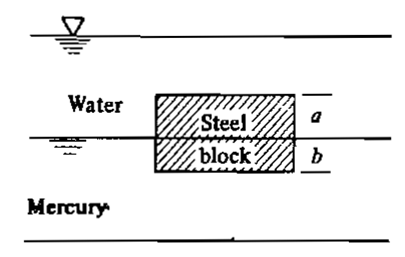

In [147]:
from PIL import Image
img = Image.open(r"figures/76.png")
img

```{Dropdown} Hint

```
Let width of block= c and length of block= d, from the summation of forces, the ratio of distances a to b can be solved as follows:


$$
\sum F_y =0 
$$

$$
F_b = W\\
$$

Where the $F_b$ is the total buoyant force from the volume submerged in mercury and the volume submerged in water:

$$
F_b = c \cdot  d \cdot  a \cdot  \rho_{water}+c \cdot  d \cdot  b \cdot  \rho_{Hg}\\
$$

and the $W$ is: 

$$
W= c \cdot  d \cdot  (a+b)\rho_{steel}\\
$$

Replacing both equation in the sum of forces we have:

$$
c \cdot  d \cdot  a \cdot \rho_{water}+ c \cdot  d \cdot  b \cdot \rho_{Hg}= c \cdot  d \cdot (a+b) \cdot \rho_{steel}\\
$$

**Solution**

In [148]:
%%render long 
s=7.85 
Ratio_ab= (s*rho_water-rho_Hg)/(rho_water-s*rho_water)

<IPython.core.display.Latex object>

---
#### Question 7 (***)

A concrete cube 0.5 m on each side is to be held in equilibrium underwater by attaching a light foam buoy to it. What minimum volume of foam is required? The specific weights of concrete and foam are 23.58 and 0.79 kN/m3 respectively. 

```{dropdown} Answer

```
$0.19 \; m^3 $ 

```{Dropdown} Hint

```
A sum of forces in the y-axis is necesssary to determine the minimum volume of foam

$$
\sum F_y=0\\
$$

$$
W_{foam}+W_{concrete}-F_{bfoam}-F_{bconcrete}=0\\
$$

$$
W_{foam}=-W_{concrete}+F_{bfoam}+F_{bconcrete}\\
$$

Replacing the equation for volume $W= \rho g V$ for each material

$$
\gamma_{foam}Vol_{foam}=-\gamma_{concrete}Vol_{concrete}+\rho_{water}g Vol_{foam}+\rho_{water} g Vol_{concrete}\\
$$

$$
Vol_{foam}(\gamma_{foam}-\rho_{water}g)=\rho_{water} g Vol_{concrete}-\gamma_{concrete}Vol_{concrete}\\
$$

$$
Vol_{foam}=\frac{\rho_{water} g Vol_{concrete}-\gamma_{concrete}Vol_{concrete}}{\gamma_{foam}-\rho_{water}g}
$$

**Solution**

In [149]:
%%render long 2
L= 0.5 #m
gamma_concrete= 23.58*1000 #N/m3
gamma_foam= 0.79*1000 #N/m3

Vol_concrete= L**3 #m3
Vol_foam= (rho_water*g*Vol_concrete-gamma_concrete*Vol_concrete)/(gamma_foam-rho_water*g) #m3

<IPython.core.display.Latex object>

### Advanced Buoyancy problems

---
#### Question 8 (***)

A wooden beam (s = 0.64) is 140 mm by 140 mm by 5 m and is hinged at A as shown below. At what angle will the beam float in the water? 

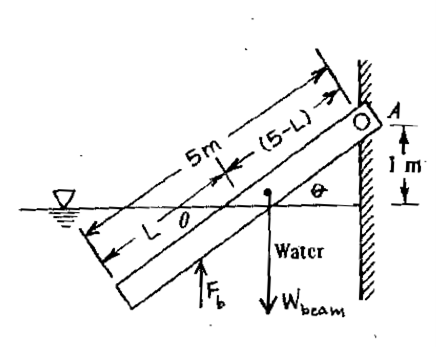

In [150]:
from PIL import Image
img = Image.open(r"figures/78.png")
img

```{dropdown} Answer


```
$19.5 \; ° $ 

```{Dropdown} Hint


```

The angle can be calculated with the momentum equation:

$$
\sum M=0 \\
F_b \cdot X_{F_b}- W \cdot X_{W}=0 \\
$$

Where: 

$$
W=g \cdot s \cdot \rho_{water} \cdot wide\cdot b \cdot L_T\\
$$

$$
F_b= g \cdot wide \cdot b \cdot L\\

$$
X_{F_b}= L_T - \frac {L \cdot cos \theta}{2}\\
$$

$$
X_{W}= \frac {L_T \cdot cos \theta}{2}\\ 
$$


Replacing the forces and the distance in the equation of momentum

$$
g \cdot L \cdot wide \cdot b \cdot L_T - \frac {L \cdot cos \theta}{2}- W\frac {L_T \cdot cos \theta}{2} =0 \\
$$

Then we can solve L.  

The angle can be calculated as:

$$
\theta=arcsin(\frac {h}{L_t-L})
$$  

**Solution**

In [151]:
%%render long 
s=0.64 
L_T= 5 #m 
wide=140/1000 #m
b=140/1000 #m
h=1 #m 

W= g*s*rho_water*wide*b*L_T #N

<IPython.core.display.Latex object>

In [152]:
from sympy.solvers import solve
from sympy import Symbol

L = Symbol("L")
ans= solve(rho_water*g*wide*b*L*(L_T-L/2)-W*L_T/2,L)
L_=round(ans[0],1)
print("L: ",L_, "m")

L:  2.00000000000000 m


In [153]:
%%render long 2
theta=degrees(asin (h/(L_T-L_))) #°

<IPython.core.display.Latex object>

---
#### Question 9 (***)[R]

Calculate the hydrostatic force and its line of action on a semi-cylindrical indentation ABC per unit width in the figure below. 

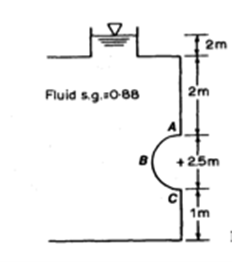

In [154]:
img = Image.open(r"figures/79.png")
img

```{dropdown} Answer


```
$115 \; kN \; at \; 10.6 \; °$ above the horizontal 

```{Dropdown} Hint Horizontal Force


```
To calculate the  hydrostatic force, the following equations should be used:

$$
F= \sqrt {F_H^2+F_V^2}
$$

The horizontal force is calculated in the vertical projection of the semi-cylindrical indendation ABC. 

$$
F_H= \rho \cdot g \cdot  h_c  \cdot A_{projection}\\
$$

$$
A= b \cdot  h_{projection}\\
$$

$$
I_c= \frac {b \cdot h^3}{12}\\
$$

$$
y_p= y_c + \frac {I_c}{y_cA}
$$

**Solution Horizontal Force**

In [155]:
%%render long 2
s=0.88
h_1=2 #m
h_2=2 #m
h_3=2.5 #m
h_4=1 #m
B=1#m

rho= s*rho_water #kg/m3
F_H= rho*g*(h_1+h_2+h_3/2)*(h_3*1) #N
y_c= h_1+h_2+h_3/2 #m
I_c= B*h_3**3/12 #m4
A= B*h_3 #m2
y_p= y_c+ I_c/(y_c*A)#m

<IPython.core.display.Latex object>

```{Dropdown} Hint Horizontal Force


```
The vertical force acting on any area is equal to the weight of the volume of liquid above it,for that reason, the following equations can be used. 

$F_V$ = Weight of fluid above the panel 

$$
F_V= \rho g Vol
$$

The centroid of a semi-circle is 

$$
X= \frac {4r}{3\pi}
$$

**Solution Vertical and Total Force**

In [156]:
%%render long 2

F_V= rho*g*((pi*(h_3/2)**2)*1)/2 #N
X= (4*2.5/2)/(3*pi) #m
F= sqrt(F_H**2+F_V**2) #N
theta= degrees(atan(F_V/F_H)) #°

<IPython.core.display.Latex object>

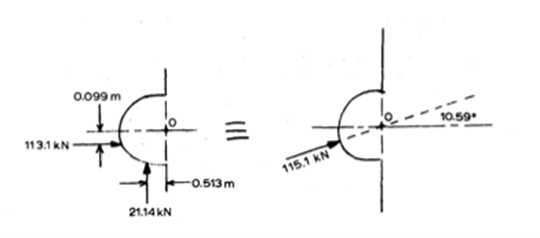

In [157]:
img = Image.open(r"figures/79s.png")
img

---
#### Question 10 (***)

A radial gate is used to seal an opening at the bottom of a dam wall as shown below. The gate is 3 m wide into the page. It has a hinge at O allowing it to be opened by applying a force F as shown. Calculate the size of the buoyancy force on the radial gate. 

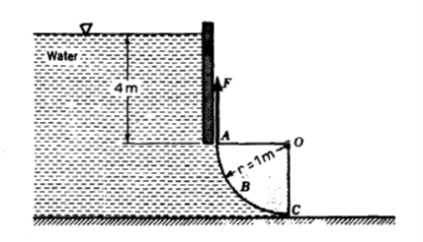

In [158]:
from PIL import Image
img = Image.open(r"figures/80.png")
img

```{dropdown} Answer

```
$140.8 \; kN $ 


```{Dropdown} Hint

```
The buoyancy force is:  

$$F_b=\rho_{water} \cdot g \cdot A \cdot B\\
A= h_{water} \cdot r+ \frac{\pi r^2}{4}  
$$

**Solution**

In [159]:
%%render long 1
B= 3 #m 
r= 1#m 
h_water= 4 #m 

F_b= rho_water*g*((h_water*r+(pi*r**2)/4))*B/1000 #kN

<IPython.core.display.Latex object>

---
#### Question 11 (* - ***)

A container with cross-section below is filled with water. The container has a width of 5 m into the page. The radius r of the quarter-cylindrical section AB is 2 m. Do the following for the quarter-cylindrical panel AB:  
a) * Calculate the pressure at A and B and draw the pressure distribution on the panel. 
b) ** Calculate the size of the horizontal hydrostatic force.   
c) ** Use the moment of area method to show that the horizontal force in (b) acts (2/3)r below the surface of the water.  
d) ** Calculate the size and line of action of the vertical hydrostatic force. 
e) ** Determine the size and direction of the resultant hydrostatic force.  
f) *** Show that the resultant hydrostatic force acts through point O. 

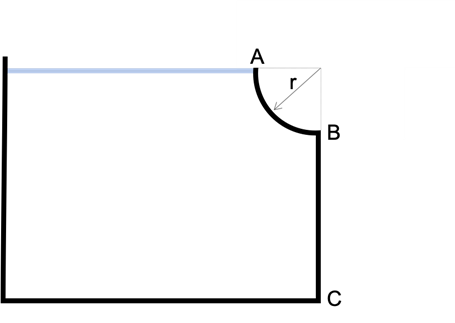

In [160]:
img = Image.open(r"figures/81.png")
img

```{dropdown} Answer



```
a)  $19.62 \; kPa $  

b) $98.1 \; kPa $ 

c)  $1.333 \; m \; = \; 2/3 \;r $ 

d) $154 \; kN \; upwards \; 0.846 \; m$ left of O

e)  $183 \; kN \; 57.5 \; °$ above the horizontal

**Question 11 (a)**

```{Dropdown} Hint

```
In A, atmosferic gauge pressure:

$$
p_A=0
$$

The pressure in B can be calculated using:

$$
p_B= \rho g h
$$

**Solution**

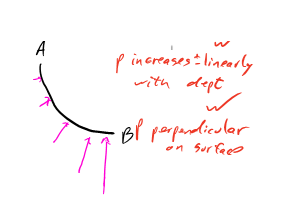

In [161]:
img = Image.open(r"figures/81s.png")
img

In [162]:
%%render long 2
B= 5 #m
r= 2 #m
p_B= rho_water*g*r/1000 #kPa

<IPython.core.display.Latex object>

**Question 11 (b)**

```{Dropdown} Hint

```
The horizontal force is calculated in the vertical projection 

$$
F_H= \rho \cdot  g \cdot  h_c \cdot A_{projection}\\
A= b \cdot  h_{projection}\\
$$

**Solution**

In [163]:
%%render long 1
h_c= r/2 #m
A= r*B #m2
F_H= rho_water*g*h_c*A/1000 #kN

<IPython.core.display.Latex object>

**Question 11 (c)**

```{Dropdown} Hint

```
The moment of area is the following equation 

$$
I_c= \frac {bh^3}{12}\\
$$

$$
y_p= y_c + \frac {I_c}{y_cA}
$$

**Solution**

In [164]:
%%render long 2
I_c= B*r**3/12 #m4
y_p= (A*h_c**2+I_c)/(A*h_c) #m from top of the panel

<IPython.core.display.Latex object>

$ \frac{2r}{3}=\frac{4}{3}=1.333 $

**Question 11 (d)**

```{Dropdown} Hint

```
The vertical force acting on any area is equal to the weight of the volume of liquid above it,for that reason, the following equations can be used. 

$F_V$ = Weight of fluid above the panel 

$$
F_V= \rho g Vol\\
$$

The line of action is the centroid of the figure

$$
X= \frac {4r}{3\pi}
$$

**Solution**

In [165]:
%%render long 2
F_V= rho_water*g*(pi*r**2)/4*B/1000 #kN
X= (4*r)/(3*pi) #m

<IPython.core.display.Latex object>

**Question 11 (e)**

```{Dropdown} Hint

```
The size and line of action of the resultant force can be calculated as:

$$
F_r=\sqrt{F_x^2+F_y^2}\\
tan\theta = \frac {F_x}{F_y}
$$

**Solution**

In [166]:
%%render long 2
F= sqrt(F_H**2+F_V**2) #kN
theta= degrees(atan(F_V/F_H)) #°

<IPython.core.display.Latex object>

**Question 11 (f)**

```{Dropdown} Hint


```
To show that the resultant hydrostatic force acts perpendicularly on the curved panel is necessary to calculate the angle between O and A (in the figure above). 

This angle can be calculated with the following equation

$$
tan\theta = \frac {X_O}{Y_O}
$$

**Solution**

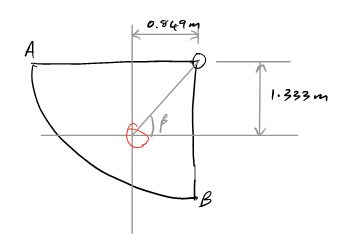

In [167]:
img = Image.open(r"figures/81s2.png")
img

In [168]:
%%render long 2
beta= degrees(atan(y_p/X)) #°

<IPython.core.display.Latex object>

$ \beta = \theta\\ $

Thus F goes through point O

---
#### Question 12 (***)

A glass tube with an internal diameter of 5 mm is inserted into a container filled with mercury. Calculate the depression in the mercury level inside the tube due to capillary forces. Assume a contact angle of 135° between the mercury and the glass. 

```{dropdown} Answer


```
$2.16 \; mm $ 

```{Dropdown} Hint

```
Using Table A.4 is possible to define the surface tension $\sigma=0.51 N/m$

$$
\sum F=0\\
$$

$$
F_b -F_{\sigma}=0\\
$$

$$
F_b= \frac {\rho g \pi d^2 h }{4}\\
$$

$$
F_{\sigma}= \pi d \sigma cos \theta\\
$$

$$
\frac {\rho g \pi d^2 h }{4}-\pi d \sigma cos \theta=0\\
$$

$$
h= \frac {4\sigma cos \theta}{\rho gd}
$$


**Solution**

In [169]:
%%render long 
d=5 #mm 
angle= 135 #°
d_m=d/1000 #m

sigma= 0.51 #N/m
theta=180-angle #°
theta_rad=(radians(theta)) #radians
h=(4*sigma*cos (theta_rad))/(rho_Hg*g*d_m) #m

<IPython.core.display.Latex object>

---
#### Question 13 (** - ****)

A water tank has a quarter-circular panel in one corner as shown in the figure below. 

a.**Calculate the size and line of action of the horizontal hydrostatic force on the panel. 

b.***Calculate the size of the vertical force on the panel. 

c.****Calculate the line of action of the vertical force on the panel. 

d.****Calculate the size and line of action of the resultant hydrostatic force on the panel. 

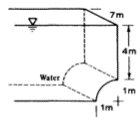

In [170]:
from PIL import Image
img = Image.open(r"figures/83.png")
img

```{dropdown} Answer

```
a)  $309 \; kN \; at \; 4.519 \; m$ below the water surface 

b) $289 \; kN $

c) $0.514 \; m $ left of side panel

d)  $423 \; kN \; at \; 43.1 \; °$ below the horizontal

**Question 13 (a)**

```{Dropdown} Hint

```
To calculate the  hydrostatic force, the following equations should be used:

$$
F= \sqrt {F_H^2+F_V^2}
$$

The horizontal force is calculated in the vertical projection of the semi-cylindrical indendation ABC. 

$$
F_H= \rho g h_c A_{projection}\\
$$

$$
A= bh_{projection}\\
$$

$$
I_c= \frac {bh^3}{12}\\
$$

$$
y_p= y_c + \frac {I_c}{y_cA}
$$

**Solution**

In [171]:
%%render long 2
B= 7 #m 
r= 1#m 
h_water= 4 #m 

h_c= h_water+r/2 #m
A= B*r #m2
F_H= rho_water*g*h_c*A/1000 #kN
I_c= B*r**3/12 #m4

y_p= h_c+I_c/(h_c*A) #m

<IPython.core.display.Latex object>

**Question 13 (b)**

```{Dropdown} Hint

```
The vertical force acting on any area is equal to the weight of the volume of liquid above it,for that reason, the following equations can be used. 

$F_y$ = Weight of fluid above the panel 

$$
F_V= \rho g Vol
$$

$$
W=\rho g [(h_{water}+r)r-\frac {\pi r^2}{4}]*B\\
$$

$$
F_W= \rho g (h_{water}+r) r *B\\
$$

$$
F_B= \rho g \frac {\pi r^2}{4}*B
$$

**Solution**

In [172]:
%%render long 1
F_W= rho_water*g*(h_water+r)*r*B/1000#kN
F_B= rho_water*g*pi*r**2*B/4/1000 #kN
F_V= F_W-F_B #kN

<IPython.core.display.Latex object>

**Question 13 (c)**

```{Dropdown} Hint

```
To calculate the line of action is necessary to use the moment equation 

$$
F_V\bar X= F_{B} \bar X_{B}- F_{w} \bar X_{w}
$$

Where: 

$ F_W $ is acting in the middle from O 


$F_V$ is acting at $ X= \frac{4r}{3\pi}$


**Solution**

In [173]:
%%render long 3

X_W= r/2 #m
X_B = 4*r/(3*pi) #m 
X= (F_W*X_W -F_B*X_B)/ F_V #m

<IPython.core.display.Latex object>

**Question 13 (d)**

```{Dropdown} Hint

```
The size and line of action of the resultant force can be calculated as:

$$
F_R= \sqrt {F_H^2+F_V^2}\\
tan\theta= \frac {F_V}{F_H}
$$


**Solution**

In [174]:
%%render long 1
F_R= sqrt(F_H**2+F_V**2) #kN
theta= degrees(atan(F_V/F_H)) #°

<IPython.core.display.Latex object>

---
#### Question 14 (** - ****)

A radial gate is used to seal an opening at the bottom of a dam wall as shown below. The gate is 3 m wide into the page. It has a hinge at O allowing it to be opened by applying a force F as shown. Do the following:  

a.	**Calculate the size and line of action of the horizontal hydrostatic force on the gate. 

b.	***Calculate the size of the vertical hydrostatic force on the gate. 

c.	****Calculate the line of action of the vertical hydrostatic force on the gate.

d.	****Calculate the size and line of action of the resultant hydrostatic force on the gate. 

e.	****Show that the hydrostatic force acts through the hinge O. 

f.	****What does this mean for the size of force required to open the gate? 

g.	How could you have known the answer for (c) without calculating the resultant hydrostatic force? 


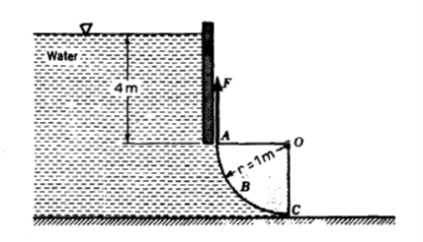

In [175]:
from PIL import Image
img = Image.open(r"figures/84.png")
img

```{dropdown} Answer

```
a)  $132.4 \; kN \; 4.159 \; m \;$below the surface 

b) $140.8 \; kN $

c) $0.424 \; m \;$left of OC

d) $193.3 \; kN \;acting \; at\; 46.8 \; ° \;$above the horizontal

**Question 14 (a)**

```{Dropdown} Hint

```
$$
F_H= \rho g h_c A_{projection}\\
$$

$$
A= bh_{projection}\\
$$

$$
I_c= \frac {bh^3}{12}\\
$$

$$
y_p= y_c + \frac {I_c}{y_cA}
$$

**Solution**

In [176]:
%%render long 
B= 3 #m 
r= 1#m 
h_water= 4 #m 
h_c= h_water+r/2 #m
A= B*r #m2
F_H= rho_water*g*h_c*A/1000 #kN
I_c= B*r**3/12 #m4

y_p= h_c+I_c/(h_c*A) #m

<IPython.core.display.Latex object>

**Question 14 (b)**

```{Dropdown} Hint

```
The vertical force acting on any area is equal to the weight of the volume of liquid above it,for that reason, the following equations can be used. 

$F_y$ = Weight of fluid above the panel 

$$
F_V= \rho g Vol
$$

**Solution**

In [177]:
%%render long 1
V= h_water*r*B + pi*r**2*B/4 #m3
F_v= rho_water*g*V/1000 #N

<IPython.core.display.Latex object>

**Question 14 (c)**

```{Dropdown} Hint


```
To calculate the line of action is necessary to use the moment equation 

$$
W_{total}\bar X= W_{rect} \bar X_{rect}+ W_{circle} \bar X_{circle}
$$

Where: 

$ \bar X_{rect} $ is acting in $r/2$


$ \bar X_{circle}$ is acting at $ X= \frac{4r}{3\pi}$

**Solution**

In [178]:
%%render long 
X_circle = 4*r/(3*pi) #m
X_rect= r/2 #m
W_circle= rho_water*g*pi*r**2*B/4 #N
W_rect= rho_water*g*B*r*h_water #N
X= (W_circle*X_circle+W_rect*X_rect)/(W_circle+W_rect)#m

<IPython.core.display.Latex object>

**Question 14 (d)**

```{Dropdown} Hint

```
$$
F_R= \sqrt {F_H^2+F_V^2}\\
tan\theta= \frac {F_v}{F_H}
$$

**Solution**

In [179]:
%%render long 2
F_R= sqrt(F_H**2+F_v**2) #kN
theta= degrees(atan(F_v/F_H)) #°

<IPython.core.display.Latex object>

**Question 14 (e)**

```{Dropdown} Hint

```
$$
\theta=arctan(\frac{F_v}{H_H})
$$

**Solution**

In [180]:
%%render long 
alpha= degrees(atan((y_p-h_water)/X))#° The angles are igual, for that reason the force acts through O.

<IPython.core.display.Latex object>

**Question 14 (f)**

**Solution**

```{Dropdown} Hint
Only determined by weight of the gate hydrostatic force does not contribute to F as it acts through hinge O.

```

**Question 14 (g)**

```{Dropdown} Hint
Pressure vectors all act through O.

```

**Solution**

In [181]:
%%render long 
X_circle = 4*r/(3*pi) #m
X_rect= r/2 #m
W_circle= rho_water*g*pi*r**2*wide/4 #N
W_rect= rho_water*g*wide*r*h_water #N
X= (W_circle*X_circle+W_rect*X_rect)/(W_circle+W_rect)#m

<IPython.core.display.Latex object>